In [17]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# 配置类
class Config:
    base_path = r"D:\大学作业\当代人工智能\实验五\project5"
    data_path = os.path.join(base_path, "data")
    train_file = os.path.join(base_path, "train.txt")
    test_file = os.path.join(base_path, "test_without_label.txt")
    
    text_model = 'bert-base-uncased'
    image_model = 'resnet50'
    
    batch_size = 16
    num_epochs = 10
    learning_rate = 2e-5
    weight_decay = 1e-4
    
    text_dim = 768
    image_dim = 2048
    hidden_dim = 256
    num_classes = 3
    dropout = 0.3
    
    image_size = 224
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    num_workers = 0

config = Config()
print(f"使用设备: {config.device}")

# 数据集类
class MultimodalDataset(Dataset):
    def __init__(self, data_list, transform=None, mode='train'):
        self.data_list = data_list
        self.transform = transform
        self.mode = mode
        self.tokenizer = BertTokenizer.from_pretrained(config.text_model)
        self.label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
        self.reverse_label_map = {v: k for k, v in self.label_map.items()}
        print(f"数据集初始化完成，共有 {len(data_list)} 条数据")
    
    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        try:
            guid, text, label = self.data_list[idx]
            
            if not text or len(text.strip()) == 0:
                text = "no text available"
            
            text_encoding = self.tokenizer(
                text,
                truncation=True,
                padding='max_length',
                max_length=64,
                return_tensors='pt'
            )
            
            img_path = os.path.join(config.data_path, f"{guid}.jpg")
            try:
                image = Image.open(img_path).convert('RGB')
            except:
                image = Image.new('RGB', (config.image_size, config.image_size), color='gray')
            
            if self.transform:
                image = self.transform(image)
            
            if self.mode != 'test':
                label_idx = self.label_map[label]
                return {
                    'input_ids': text_encoding['input_ids'].squeeze(0),
                    'attention_mask': text_encoding['attention_mask'].squeeze(0),
                    'image': image,
                    'label': torch.tensor(label_idx, dtype=torch.long),
                    'guid': guid
                }
            else:
                return {
                    'input_ids': text_encoding['input_ids'].squeeze(0),
                    'attention_mask': text_encoding['attention_mask'].squeeze(0),
                    'image': image,
                    'guid': guid
                }
        except Exception as e:
            print(f"处理数据 {idx} 时出错: {e}")
            return self.__getitem__((idx + 1) % len(self.data_list))

# 加载数据
def load_data():
    train_data = []
    with open(config.train_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in tqdm(lines[1:], desc="加载训练数据"):
            line = line.strip()
            if line:
                parts = line.split(',')
                if len(parts) >= 2:
                    guid, label = parts[0], parts[1]
                    txt_path = os.path.join(config.data_path, f"{guid}.txt")
                    try:
                        with open(txt_path, 'r', encoding='utf-8', errors='ignore') as txt_f:
                            text = txt_f.read().strip()
                    except:
                        text = ""
                    train_data.append((guid, text, label))
    
    test_data = []
    with open(config.test_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in tqdm(lines[1:], desc="加载测试数据"):
            line = line.strip()
            if line:
                parts = line.split(',')
                if len(parts) >= 2:
                    guid, label = parts[0], parts[1]
                else:
                    guid = parts[0]
                    label = None
                txt_path = os.path.join(config.data_path, f"{guid}.txt")
                try:
                    with open(txt_path, 'r', encoding='utf-8', errors='ignore') as txt_f:
                        text = txt_f.read().strip()
                except:
                    text = ""
                test_data.append((guid, text, label))
    
    print(f"加载了 {len(train_data)} 条训练数据, {len(test_data)} 条测试数据")
    return train_data, test_data

# 多模态融合模型
class MultimodalModel(nn.Module):
    def __init__(self):
        super(MultimodalModel, self).__init__()
        
        self.text_encoder = BertModel.from_pretrained(config.text_model)
        for param in self.text_encoder.parameters():
            param.requires_grad = False
        for param in self.text_encoder.encoder.layer[-2:].parameters():
            param.requires_grad = True
        
        self.image_encoder = models.resnet50(pretrained=True)
        self.image_encoder = nn.Sequential(*list(self.image_encoder.children())[:-2])
        self.image_pool = nn.AdaptiveAvgPool2d((1, 1))
        for param in self.image_encoder.parameters():
            param.requires_grad = False
        for param in list(self.image_encoder.children())[-4:]:
            for p in param.parameters():
                p.requires_grad = True
        
        self.text_fc = nn.Linear(config.text_dim, config.hidden_dim)
        self.image_fc = nn.Linear(2048, config.hidden_dim)
        self.fusion = nn.Sequential(
            nn.Linear(config.hidden_dim * 2, config.hidden_dim),
            nn.ReLU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dim, config.num_classes)
        )
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(config.dropout)
    
    def forward(self, input_ids, attention_mask, image):
        text_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_features = text_out.last_hidden_state[:, 0, :]
        text_features = self.relu(self.text_fc(text_features))
        text_features = self.dropout(text_features)
        
        image_features = self.image_encoder(image)
        image_features = self.image_pool(image_features)
        image_features = image_features.view(image_features.size(0), -1)
        image_features = self.relu(self.image_fc(image_features))
        image_features = self.dropout(image_features)
        
        fused = torch.cat([text_features, image_features], dim=1)
        output = self.fusion(fused)
        
        return output

# 训练器类
class Trainer:
    def __init__(self, model, train_loader, val_loader, model_name):
        self.model = model.to(config.device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.model_name = model_name
        
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=config.learning_rate,
            weight_decay=config.weight_decay
        )
        
        self.best_accuracy = 0
        self.history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    def train_epoch(self):
        self.model.train()
        total_loss = 0
        total_batches = len(self.train_loader)
        
        for batch_idx, batch in enumerate(tqdm(self.train_loader, desc="训练中", leave=False)):
            input_ids = batch['input_ids'].to(config.device)
            attention_mask = batch['attention_mask'].to(config.device)
            images = batch['image'].to(config.device)
            labels = batch['label'].to(config.device)
            
            self.optimizer.zero_grad()
            outputs = self.model(input_ids, attention_mask, images)
            loss = self.criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()
            
            total_loss += loss.item()
            
            if (batch_idx + 1) % 100 == 0:
                print(f"  Batch {batch_idx+1}/{total_batches}, Loss: {loss.item():.4f}")
        
        return total_loss / total_batches
    
    def validate(self):
        self.model.eval()
        total_loss = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc="验证中", leave=False):
                input_ids = batch['input_ids'].to(config.device)
                attention_mask = batch['attention_mask'].to(config.device)
                images = batch['image'].to(config.device)
                labels = batch['label'].to(config.device)
                
                outputs = self.model(input_ids, attention_mask, images)
                loss = self.criterion(outputs, labels)
                total_loss += loss.item()
                
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        accuracy = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='weighted')
        return total_loss / len(self.val_loader), accuracy, f1, all_preds, all_labels
    
    def train(self, epochs=None):
        if epochs is None:
            epochs = config.num_epochs
            
        print(f"\n开始训练 {self.model_name}，共 {epochs} 个epoch...")
        
        for epoch in range(epochs):
            start_time = time.time()
            print(f"\nEpoch {epoch+1}/{epochs}:")
            
            train_loss = self.train_epoch()
            val_loss, val_acc, val_f1, _, _ = self.validate()
            
            epoch_time = time.time() - start_time
            
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            
            print(f"  Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
            print(f"  Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
            print(f"  耗时: {epoch_time:.1f}秒")
            
            if val_acc > self.best_accuracy:
                self.best_accuracy = val_acc
                torch.save(self.model.state_dict(), f'best_{self.model_name}.pth')
                print(f"  保存最佳模型，准确率: {val_acc:.4f}")
        
        print(f"\n{self.model_name} 训练完成，最佳验证准确率: {self.best_accuracy:.4f}")
    
    def get_results(self):
        self.model.load_state_dict(torch.load(f'best_{self.model_name}.pth'))
        val_loss, val_acc, val_f1, preds, labels = self.validate()
        
        report = classification_report(
            labels, preds, 
            target_names=['positive', 'neutral', 'negative'],
            output_dict=True
        )
        
        return {
            'accuracy': val_acc,
            'weighted_f1': val_f1,
            'history': self.history
        }

# 主函数：多模态模型训练和预测
def run_multimodal_experiment():
    print("=" * 60)
    print("多模态情感分类模型训练和预测")
    print("=" * 60)
    
    # 1. 加载数据
    print("\n1. 加载数据...")
    train_data, test_data = load_data()
    
    # 2. 划分训练集和验证集（使用全部数据）
    print(f"\n2. 划分训练集和验证集...")
    print(f"训练数据总数: {len(train_data)}")
    
    # 直接使用全部训练数据，而不是采样
    train_data_full, val_data = train_test_split(
        train_data, 
        test_size=0.2, 
        random_state=42, 
        stratify=[d[2] for d in train_data]  # 按标签分层抽样
    )
    
    print(f"训练集: {len(train_data_full)}, 验证集: {len(val_data)}, 测试集: {len(test_data)}")
    
    # 3. 数据预处理
    train_transform = transforms.Compose([
        transforms.Resize((config.image_size, config.image_size)),
        transforms.RandomHorizontalFlip(p=0.3),  # 添加数据增强
        transforms.RandomRotation(10),  # 添加数据增强
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((config.image_size, config.image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # 4. 创建数据集和数据加载器
    print("\n3. 创建数据集...")
    train_dataset = MultimodalDataset(train_data_full, transform=train_transform)
    val_dataset = MultimodalDataset(val_data, transform=val_transform)
    test_dataset = MultimodalDataset(test_data, transform=val_transform, mode='test')
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=config.num_workers
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers
    )
    
    # 5. 训练多模态模型
    print("\n" + "=" * 60)
    print("训练多模态模型")
    print("=" * 60)
    
    model = MultimodalModel()
    print(f"模型参数总数: {sum(p.numel() for p in model.parameters())}")
    print(f"可训练参数数: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
    
    trainer = Trainer(model, train_loader, val_loader, "multimodal")
    trainer.train(epochs=config.num_epochs)
    results = trainer.get_results()
    
    # 保存结果
    results_df = pd.DataFrame([['多模态模型', results['accuracy'], results['weighted_f1']]], 
                             columns=['模型', '准确率', '加权F1'])
    results_df.to_csv('multimodal_results.csv', index=False, float_format='%.4f')
    
    # 6. 在测试集上进行预测
    print("\n" + "=" * 60)
    print("在测试集上进行预测")
    print("=" * 60)
    
    # 加载最佳模型
    model.load_state_dict(torch.load('best_multimodal.pth'))
    model = model.to(config.device)
    model.eval()
    
    predictions = []
    guids = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="测试集预测"):
            input_ids = batch['input_ids'].to(config.device)
            attention_mask = batch['attention_mask'].to(config.device)
            images = batch['image'].to(config.device)
            batch_guids = batch['guid']
            
            outputs = model(input_ids, attention_mask, images)
            _, preds = torch.max(outputs, 1)
            
            predictions.extend(preds.cpu().numpy())
            guids.extend(batch_guids)
    
    # 映射回标签
    label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
    reverse_map = {v: k for k, v in label_map.items()}
    predictions_labels = [reverse_map[pred] for pred in predictions]
    
    # 保存预测结果映射
    pred_dict = dict(zip(guids, predictions_labels))
    
    # 更新原始文件
    with open(config.test_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    new_lines = [lines[0]]  # 标题行
    for line in lines[1:]:
        line = line.strip()
        if line:
            parts = line.split(',')
            guid = parts[0]
            pred_label = pred_dict.get(guid, 'neutral')
            new_lines.append(f'{guid},{pred_label}\n')
    
    # 直接覆盖原测试文件
    output_file = config.test_file  
    with open(output_file, 'w', encoding='utf-8') as f:
        f.writelines(new_lines)
    
    print(f"\n多模态模型预测结果已保存到: {output_file}")
    print(f"  共预测了 {len(predictions)} 条测试数据")
    print(f"  验证准确率: {results['accuracy']:.4f}")
    print(f"  加权F1分数: {results['weighted_f1']:.4f}")
    
    # 显示预测结果分布
    print("\n预测结果分布:")
    for label_name in ['positive', 'neutral', 'negative']:
        count = list(predictions_labels).count(label_name)
        print(f"  {label_name}: {count} ({count/len(predictions_labels)*100:.1f}%)")
    
    return results, pred_dict

# 运行多模态实验
if __name__ == "__main__":
    try:
        multimodal_results, multimodal_predictions = run_multimodal_experiment()

    except Exception as e:
        print(f"运行过程中出现错误: {e}")
        import traceback
        traceback.print_exc()

使用设备: cpu
多模态情感分类模型训练和预测

1. 加载数据...


加载测试数据: 100%|████████████████████████████████████████████████████████████████| 511/511 [00:00<00:00, 7405.62it/s]


加载了 4000 条训练数据, 511 条测试数据

2. 划分训练集和验证集...
训练数据总数: 4000
训练集: 3200, 验证集: 800, 测试集: 511

3. 创建数据集...
数据集初始化完成，共有 3200 条数据
数据集初始化完成，共有 800 条数据
数据集初始化完成，共有 511 条数据

训练多模态模型
模型参数总数: 133843779
可训练参数数: 38527747

开始训练 multimodal，共 10 个epoch...

Epoch 1/10:


训练中:  50%|████████████████████████████████████                                    | 100/200 [05:45<05:51,  3.52s/it]

  Batch 100/200, Loss: 0.6783


...

  Batch 200/200, Loss: 0.0183


  Train Loss: 0.1176, Val Loss: 1.5773
  Val Acc: 0.6963, Val F1: 0.6766
  耗时: 803.0秒

multimodal 训练完成，最佳验证准确率: 0.7212



在测试集上进行预测


测试集预测: 100%|██████████████████████████████████████████████████████████████████████| 32/32 [00:49<00:00,  1.56s/it]


多模态模型预测结果已保存到: D:\大学作业\当代人工智能\实验五\project5\test_without_label.txt
  共预测了 511 条测试数据
  验证准确率: 0.7212
  加权F1分数: 0.6891

预测结果分布:
  positive: 378 (74.0%)
  neutral: 5 (1.0%)
  negative: 128 (25.0%)


消融实验


加载测试数据: 100%|████████████████████████████████████████████████████████████████| 511/511 [00:00<00:00, 9283.61it/s]


加载了 4000 条训练数据, 511 条测试数据

进行消融实验:
训练数据总数: 4000
验证集大小: 800
测试集大小: 511
数据集初始化完成，共有 800 条数据

加载训练好的多模态模型...
找到模型文件: best_multimodal.pth
模型加载成功！

测试：仅文本输入



仅文本输入详细分类报告:
----------------------------------------
              precision    recall  f1-score   support

    positive       0.80      0.67      0.72       478
     neutral       0.44      0.25      0.32        84
    negative       0.53      0.78      0.63       238

    accuracy                           0.66       800
   macro avg       0.59      0.56      0.56       800
weighted avg       0.68      0.66      0.65       800

仅文本输入 - 准确率: 0.6550, 加权F1: 0.6528

测试：仅图像输入



仅图像输入详细分类报告:
----------------------------------------
              precision    recall  f1-score   support

    positive       0.61      1.00      0.76       478
     neutral       0.00      0.00      0.00        84
    negative       0.86      0.08      0.15       238

    accuracy                           0.62       800
   macro avg       0.49      0.36      0.30       800
weighted avg       0.62      0.62      0.50       800

仅图像输入 - 准确率: 0.6200, 加权F1: 0.4977

测试：多模态输入



多模态输入详细分类报告:
----------------------------------------
              precision    recall  f1-score   support

    positive       0.74      0.90      0.81       478
     neutral       0.75      0.11      0.19        84
    negative       0.67      0.58      0.62       238

    accuracy                           0.72       800
   macro avg       0.72      0.53      0.54       800
weighted avg       0.72      0.72      0.69       800

多模态输入 - 准确率: 0.7212, 加权F1: 0.6891

消融实验结果汇总

同一多模态模型在不同输入方式下的表现:
------------------------------------------------------------
   输入方式     准确率     加权F1
  仅文本输入 0.65500 0.652790
  仅图像输入 0.62000 0.497676
完整多模态输入 0.72125 0.689128


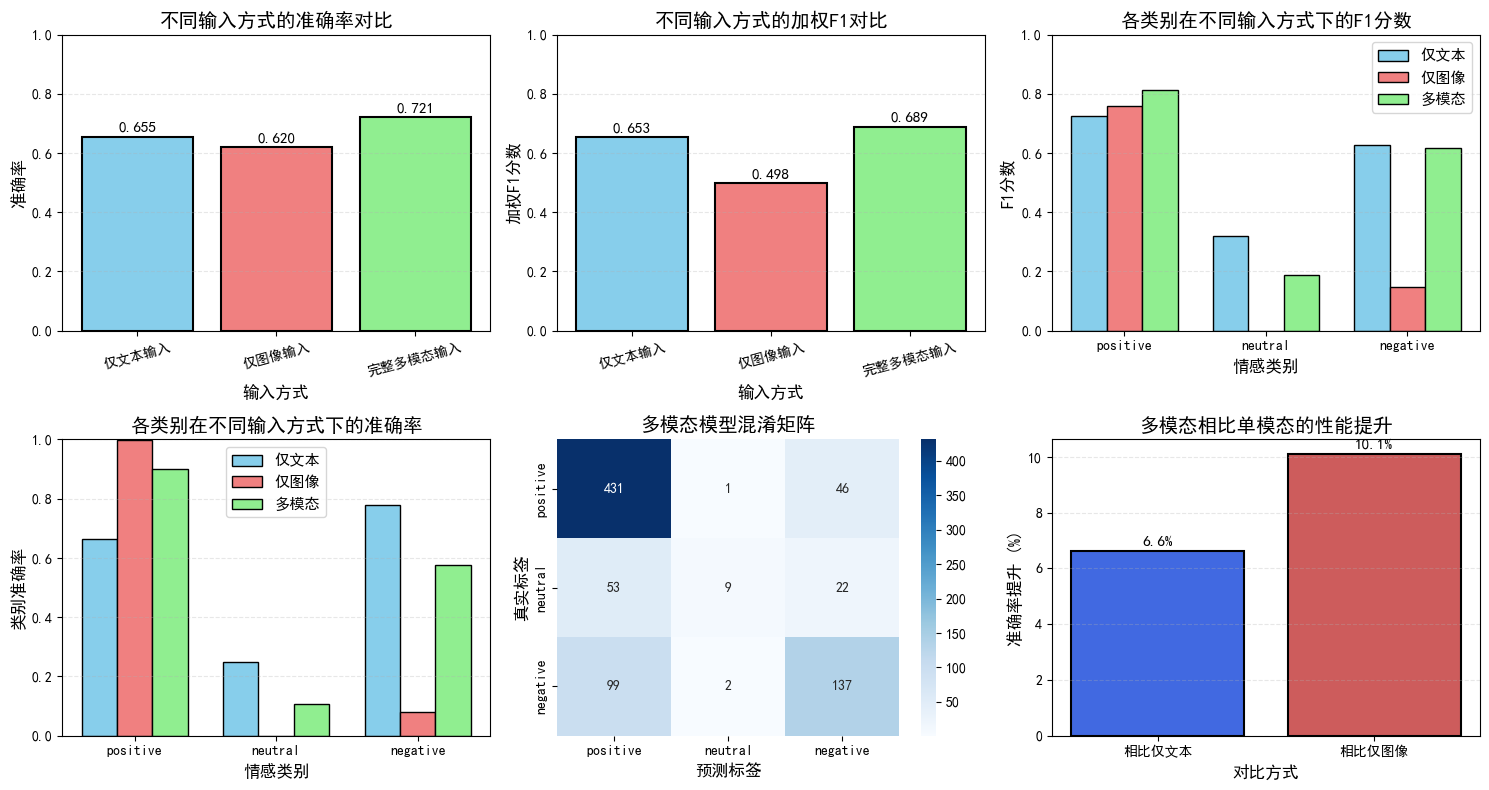


消融实验总结

实验设置:
- 验证集大小: 800 条数据
- 使用模型: 训练好的多模态模型
- 评估方式: 同一模型在不同输入条件下的表现

实验结果:
1. 仅文本输入准确率: 0.6550 (加权F1: 0.6528)
2. 仅图像输入准确率: 0.6200 (加权F1: 0.4977)
3. 完整多模态输入准确率: 0.7212 (加权F1: 0.6891)

性能提升分析:
多模态相比仅文本提升: 6.62% (绝对), 10.11% (相对)
多模态相比仅图像提升: 10.12% (绝对), 16.33% (相对)


In [18]:
print("=" * 60)
print("消融实验")
print("=" * 60)

# 重新导入必要的模块，确保 models 是 torchvision.models
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
from transformers import BertTokenizer, BertModel
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

# 确保使用全局的config配置
# （如果是独立运行，需要先定义Config类，这里假设主实验的config已加载）

# 重新加载数据（使用全部数据）
train_data, test_data = load_data()

# 使用与主实验相同的划分方式（使用全部数据）
train_data_full, val_data = train_test_split(
    train_data, 
    test_size=0.2, 
    random_state=42, 
    stratify=[d[2] for d in train_data]
)

print(f"\n进行消融实验:")
print(f"训练数据总数: {len(train_data)}")
print(f"验证集大小: {len(val_data)}")
print(f"测试集大小: {len(test_data)}")

# 数据预处理
val_transform = transforms.Compose([
    transforms.Resize((config.image_size, config.image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 创建验证集（使用全部验证数据）
val_dataset = MultimodalDataset(val_data, transform=val_transform)
val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers
)

# 重新定义 MultimodalModel 类，确保正确引用 models
class MultimodalModel(nn.Module):
    def __init__(self):
        super(MultimodalModel, self).__init__()
        
        self.text_encoder = BertModel.from_pretrained(config.text_model)
        for param in self.text_encoder.parameters():
            param.requires_grad = False
        for param in self.text_encoder.encoder.layer[-2:].parameters():
            param.requires_grad = True
        
        # 明确使用 torchvision.models
        self.image_encoder = models.resnet50(pretrained=True)
        self.image_encoder = nn.Sequential(*list(self.image_encoder.children())[:-2])
        self.image_pool = nn.AdaptiveAvgPool2d((1, 1))
        for param in self.image_encoder.parameters():
            param.requires_grad = False
        for param in list(self.image_encoder.children())[-4:]:
            for p in param.parameters():
                p.requires_grad = True
        
        self.text_fc = nn.Linear(config.text_dim, config.hidden_dim)
        self.image_fc = nn.Linear(2048, config.hidden_dim)
        self.fusion = nn.Sequential(
            nn.Linear(config.hidden_dim * 2, config.hidden_dim),
            nn.ReLU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dim, config.num_classes)
        )
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(config.dropout)
    
    def forward(self, input_ids, attention_mask, image):
        text_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_features = text_out.last_hidden_state[:, 0, :]
        text_features = self.relu(self.text_fc(text_features))
        text_features = self.dropout(text_features)
        
        image_features = self.image_encoder(image)
        image_features = self.image_pool(image_features)
        image_features = image_features.view(image_features.size(0), -1)
        image_features = self.relu(self.image_fc(image_features))
        image_features = self.dropout(image_features)
        
        fused = torch.cat([text_features, image_features], dim=1)
        output = self.fusion(fused)
        
        return output

# 加载训练好的多模态模型
print("\n加载训练好的多模态模型...")
try:
    model = MultimodalModel()
    # 检查模型文件是否存在
    model_path = 'best_multimodal.pth'
    if os.path.exists(model_path):
        print(f"找到模型文件: {model_path}")
        model.load_state_dict(torch.load(model_path, map_location=config.device))
        model = model.to(config.device)
        model.eval()
        print("模型加载成功！")
    else:
        print(f"模型文件不存在: {model_path}")
        print("请先运行主实验进行训练")
        exit()
except Exception as e:
    print(f"模型加载失败: {e}")
    import traceback
    traceback.print_exc()
    exit()

# 1. 测试仅文本输入
print("\n" + "=" * 30)
print("测试：仅文本输入")
print("=" * 30)

def evaluate_text_only():
    """仅使用文本数据进行评估"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="仅文本评估", leave=False):
            input_ids = batch['input_ids'].to(config.device)
            attention_mask = batch['attention_mask'].to(config.device)
            labels = batch['label'].to(config.device)
            
            # 获取文本特征
            text_out = model.text_encoder(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            text_features = text_out.last_hidden_state[:, 0, :]
            text_features = model.relu(model.text_fc(text_features))
            text_features = model.dropout(text_features)
            
            # 创建零图像特征
            batch_size = input_ids.size(0)
            zero_image_features = torch.zeros(batch_size, model.image_fc.out_features).to(config.device)
            
            # 融合特征（文本 + 零图像）
            fused = torch.cat([text_features, zero_image_features], dim=1)
            output = model.fusion(fused)
            
            _, preds = torch.max(output, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # 关键修改1：强制转换为Python原生float
    accuracy = float(accuracy_score(all_labels, all_preds))
    f1 = float(f1_score(all_labels, all_preds, average='weighted'))
    
    # 详细分类报告
    print("\n仅文本输入详细分类报告:")
    print("-" * 40)
    report = classification_report(all_labels, all_preds, 
                                   target_names=['positive', 'neutral', 'negative'])
    print(report)
    
    return accuracy, f1, all_preds, all_labels

text_only_acc, text_only_f1, text_preds, text_labels = evaluate_text_only()
print(f"仅文本输入 - 准确率: {text_only_acc:.4f}, 加权F1: {text_only_f1:.4f}")

# 2. 测试仅图像输入
print("\n" + "=" * 30)
print("测试：仅图像输入")
print("=" * 30)

def evaluate_image_only():
    """仅使用图像数据进行评估"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="仅图像评估", leave=False):
            images = batch['image'].to(config.device)
            labels = batch['label'].to(config.device)
            
            # 获取图像特征
            image_features = model.image_encoder(images)
            image_features = model.image_pool(image_features)
            image_features = image_features.view(image_features.size(0), -1)
            image_features = model.relu(model.image_fc(image_features))
            image_features = model.dropout(image_features)
            
            # 创建零文本特征
            batch_size = images.size(0)
            zero_text_features = torch.zeros(batch_size, model.text_fc.out_features).to(config.device)
            
            # 融合特征（零文本 + 图像）
            fused = torch.cat([zero_text_features, image_features], dim=1)
            output = model.fusion(fused)
            
            _, preds = torch.max(output, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # 关键修改2：强制转换为Python原生float
    accuracy = float(accuracy_score(all_labels, all_preds))
    f1 = float(f1_score(all_labels, all_preds, average='weighted'))
    
    # 详细分类报告
    print("\n仅图像输入详细分类报告:")
    print("-" * 40)
    report = classification_report(all_labels, all_preds, 
                                   target_names=['positive', 'neutral', 'negative'])
    print(report)
    
    return accuracy, f1, all_preds, all_labels

image_only_acc, image_only_f1, image_preds, image_labels = evaluate_image_only()
print(f"仅图像输入 - 准确率: {image_only_acc:.4f}, 加权F1: {image_only_f1:.4f}")

# 3. 完整多模态测试（用于对比）
print("\n" + "=" * 30)
print("测试：多模态输入")
print("=" * 30)

def evaluate_full_multimodal():
    """使用多模态数据进行评估"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="完整多模态评估", leave=False):
            input_ids = batch['input_ids'].to(config.device)
            attention_mask = batch['attention_mask'].to(config.device)
            images = batch['image'].to(config.device)
            labels = batch['label'].to(config.device)
            
            outputs = model(input_ids, attention_mask, images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # 关键修改3：强制转换为Python原生float
    accuracy = float(accuracy_score(all_labels, all_preds))
    f1 = float(f1_score(all_labels, all_preds, average='weighted'))
    
    # 详细分类报告
    print("\n多模态输入详细分类报告:")
    print("-" * 40)
    report = classification_report(all_labels, all_preds, 
                                   target_names=['positive', 'neutral', 'negative'])
    print(report)
    
    return accuracy, f1, all_preds, all_labels

full_acc, full_f1, full_preds, full_labels = evaluate_full_multimodal()
print(f"多模态输入 - 准确率: {full_acc:.4f}, 加权F1: {full_f1:.4f}")

# 4. 结果汇总和对比
print("\n" + "=" * 60)
print("消融实验结果汇总")
print("=" * 60)

# 直接使用已经确保是Python原生float的值
results_data = [
    ['仅文本输入', text_only_acc, text_only_f1],
    ['仅图像输入', image_only_acc, image_only_f1],
    ['完整多模态输入', full_acc, full_f1]
]

results_df = pd.DataFrame(results_data, columns=['输入方式', '准确率', '加权F1'])
print("\n同一多模态模型在不同输入方式下的表现:")
print("-" * 60)
print(results_df.to_string(index=False))

# 5. 绘制性能对比图
plt.figure(figsize=(15, 8))

# 子图1：准确率对比
plt.subplot(2, 3, 1)
models_list = results_df['输入方式']
accuracies = results_df['准确率'].values

colors = ['skyblue', 'lightcoral', 'lightgreen']
bars = plt.bar(models_list, accuracies, color=colors, edgecolor='black', linewidth=1.5)
plt.xlabel('输入方式', fontsize=12)
plt.ylabel('准确率', fontsize=12)
plt.title('不同输入方式的准确率对比', fontsize=14, fontweight='bold')
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.xticks(rotation=15)

# 在柱子上显示数值
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 子图2：加权F1对比
plt.subplot(2, 3, 2)
f1_scores = results_df['加权F1'].values
bars = plt.bar(models_list, f1_scores, color=colors, edgecolor='black', linewidth=1.5)
plt.xlabel('输入方式', fontsize=12)
plt.ylabel('加权F1分数', fontsize=12)
plt.title('不同输入方式的加权F1对比', fontsize=14, fontweight='bold')
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.xticks(rotation=15)

for bar, f1 in zip(bars, f1_scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{f1:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 子图3：各类别F1分数对比
plt.subplot(2, 3, 3)

# 获取详细分类报告
def get_classification_details(preds, labels):
    from sklearn.metrics import precision_recall_fscore_support
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average=None)
    return precision.astype(float), recall.astype(float), f1.astype(float)

text_precision, text_recall, text_f1 = get_classification_details(text_preds, text_labels)
image_precision, image_recall, image_f1 = get_classification_details(image_preds, image_labels)
full_precision, full_recall, full_f1_class = get_classification_details(full_preds, full_labels)

x = np.arange(3)  # 3个类别
width = 0.25

bars1 = plt.bar(x - width, text_f1, width, label='仅文本', color='skyblue', edgecolor='black')
bars2 = plt.bar(x, image_f1, width, label='仅图像', color='lightcoral', edgecolor='black')
bars3 = plt.bar(x + width, full_f1_class, width, label='多模态', color='lightgreen', edgecolor='black')

plt.xlabel('情感类别', fontsize=12)
plt.ylabel('F1分数', fontsize=12)
plt.title('各类别在不同输入方式下的F1分数', fontsize=14, fontweight='bold')
plt.xticks(x, ['positive', 'neutral', 'negative'])
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.ylim(0, 1.0)

# 子图4：各类别准确率对比
plt.subplot(2, 3, 4)
categories = ['positive', 'neutral', 'negative']

# 计算每个类别的准确率
def get_class_accuracy(preds, labels):
    cm = confusion_matrix(labels, preds)
    class_acc = cm.diagonal() / cm.sum(axis=1)
    return class_acc.astype(float)

text_class_acc = get_class_accuracy(text_preds, text_labels)
image_class_acc = get_class_accuracy(image_preds, image_labels)
full_class_acc = get_class_accuracy(full_preds, full_labels)

bars1 = plt.bar(x - width, text_class_acc, width, label='仅文本', color='skyblue', edgecolor='black')
bars2 = plt.bar(x, image_class_acc, width, label='仅图像', color='lightcoral', edgecolor='black')
bars3 = plt.bar(x + width, full_class_acc, width, label='多模态', color='lightgreen', edgecolor='black')

plt.xlabel('情感类别', fontsize=12)
plt.ylabel('类别准确率', fontsize=12)
plt.title('各类别在不同输入方式下的准确率', fontsize=14, fontweight='bold')
plt.xticks(x, categories)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.ylim(0, 1.0)

# 子图5：混淆矩阵热力图
plt.subplot(2, 3, 5)
# 使用多模态的混淆矩阵
cm = confusion_matrix(full_labels, full_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['positive', 'neutral', 'negative'],
            yticklabels=['positive', 'neutral', 'negative'])
plt.xlabel('预测标签', fontsize=12)
plt.ylabel('真实标签', fontsize=12)
plt.title('多模态模型混淆矩阵', fontsize=14, fontweight='bold')

# 子图6：性能提升百分比
plt.subplot(2, 3, 6)
# 计算性能提升
text_improvement = (full_acc - text_only_acc) * 100
image_improvement = (full_acc - image_only_acc) * 100

improvements = [text_improvement, image_improvement]
labels_imp = ['相比仅文本', '相比仅图像']
colors_imp = ['royalblue', 'indianred']

bars = plt.bar(labels_imp, improvements, color=colors_imp, edgecolor='black', linewidth=1.5)
plt.xlabel('对比方式', fontsize=12)
plt.ylabel('准确率提升 (%)', fontsize=12)
plt.title('多模态相比单模态的性能提升', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y', linestyle='--')

# 添加数值标签
for bar, imp in zip(bars, improvements):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{imp:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 6. 实验总结
print("\n" + "="*60)
print("消融实验总结")
print("="*60)

print(f"\n实验设置:")
print(f"- 验证集大小: {len(val_data)} 条数据")
print(f"- 使用模型: 训练好的多模态模型")
print(f"- 评估方式: 同一模型在不同输入条件下的表现")

print(f"\n实验结果:")
print(f"1. 仅文本输入准确率: {text_only_acc:.4f} (加权F1: {text_only_f1:.4f})")
print(f"2. 仅图像输入准确率: {image_only_acc:.4f} (加权F1: {image_only_f1:.4f})") 
print(f"3. 完整多模态输入准确率: {full_acc:.4f} (加权F1: {full_f1:.4f})")

# 计算性能提升
text_improvement = (full_acc - text_only_acc) * 100
image_improvement = (full_acc - image_only_acc) * 100

# 计算相对提升
text_rel_improvement = (full_acc / text_only_acc - 1) * 100 if text_only_acc > 0 else 0
image_rel_improvement = (full_acc / image_only_acc - 1) * 100 if image_only_acc > 0 else 0

print(f"\n性能提升分析:")
print(f"多模态相比仅文本提升: {text_improvement:.2f}% (绝对), {text_rel_improvement:.2f}% (相对)")
print(f"多模态相比仅图像提升: {image_improvement:.2f}% (绝对), {image_rel_improvement:.2f}% (相对)")

In [11]:
import os
import re
import random
import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

# 关键：补充缺失的导入
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from transformers import BertTokenizer, BertModel, AdamW, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight  # 补充这个关键导入
import seaborn as sns

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# 配置类 - 优化默认参数
class Config:
    base_path = r"D:\大学作业\当代人工智能\实验五\project5"
    data_path = os.path.join(base_path, "data")
    train_file = os.path.join(base_path, "train.txt")
    test_file = os.path.join(base_path, "test_without_label.txt")
    
    text_model = 'bert-base-uncased'
    image_model = 'resnet50'
    
    # CPU训练时减小batch_size避免内存不足
    batch_size = 8 if torch.cuda.is_available() else 4
    num_epochs = 8  # 减少epoch避免过拟合
    learning_rate = 2e-5
    weight_decay = 1e-4
    warmup_ratio = 0.1
    
    text_dim = 768
    image_dim = 2048
    hidden_dim = 256
    num_classes = 3
    dropout = 0.3
    
    image_size = 224
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    num_workers = 0
    
    # 融合方式选择
    fusion_method = 'attention'
    
    # 是否使用数据增强
    use_data_aug = True
    
    # 是否平衡数据集
    balance_dataset = True
    
    # 早停参数
    patience = 3  # 3个epoch无提升则停止
    min_delta = 0.001  # 最小提升阈值

config = Config()
print(f"使用设备: {config.device}")
print(f"批次大小: {config.batch_size}")
print(f"融合方式: {config.fusion_method}")

# ====================== 1. 优化的数据预处理 ======================

# 全局初始化tokenizer和model，避免重复下载
global_tokenizer = None
def get_bert_tokenizer():
    """单例模式获取tokenizer，避免重复下载"""
    global global_tokenizer
    if global_tokenizer is None:
        try:
            # 优先使用本地文件
            global_tokenizer = BertTokenizer.from_pretrained(
                config.text_model, 
                local_files_only=True,
                cache_dir='./cache'
            )
        except:
            try:
                # 尝试下载
                global_tokenizer = BertTokenizer.from_pretrained(
                    config.text_model,
                    cache_dir='./cache'
                )
            except Exception as e:
                print(f"Tokenizer下载失败，使用基础配置: {e}")
                # 备用方案：手动创建tokenizer
                from transformers import BasicTokenizer
                global_tokenizer = BasicTokenizer()
    return global_tokenizer

def get_bert_model():
    """单例模式获取BERT模型"""
    try:
        model = BertModel.from_pretrained(
            config.text_model,
            local_files_only=True,
            cache_dir='./cache'
        )
    except:
        model = BertModel.from_pretrained(
            config.text_model,
            cache_dir='./cache'
        )
    return model

# 文本清洗函数
def clean_text(text):
    if not text or len(text.strip()) == 0:
        return "no text available"
    
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.lower()
    
    if len(text.split()) < 2:
        text = "no meaningful text"
    
    return text

# 自定义图片增强
class RandomColorJitter:
    def __init__(self, brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1):
        self.brightness = brightness
        self.contrast = contrast
        self.saturation = saturation
        self.hue = hue
        
    def __call__(self, img):
        if random.random() < 0.5:
            enhancer = ImageEnhance.Brightness(img)
            img = enhancer.enhance(random.uniform(1-self.brightness, 1+self.brightness))
        
        if random.random() < 0.5:
            enhancer = ImageEnhance.Contrast(img)
            img = enhancer.enhance(random.uniform(1-self.contrast, 1+self.contrast))
        
        return img

# 优化的数据集类
class MultimodalDataset(Dataset):
    def __init__(self, data_list, transform=None, mode='train'):
        self.data_list = data_list
        self.transform = transform
        self.mode = mode
        self.tokenizer = get_bert_tokenizer()
        self.label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
        self.reverse_label_map = {v: k for k, v in self.label_map.items()}
        
        # 预生成默认图片，避免重复创建
        self.default_image = Image.new('RGB', (config.image_size, config.image_size))
        pixels = self.default_image.load()
        for i in range(self.default_image.size[0]):
            for j in range(self.default_image.size[1]):
                rand_val = random.randint(180, 220)
                pixels[i, j] = (rand_val, rand_val, rand_val)
        
        print(f"数据集初始化完成，共有 {len(data_list)} 条数据")
    
    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        try:
            guid, text, label = self.data_list[idx]
            text = clean_text(text)
            
            # 兼容不同的tokenizer类型
            if hasattr(self.tokenizer, 'encode_plus'):
                text_encoding = self.tokenizer(
                    text,
                    truncation=True,
                    padding='max_length',
                    max_length=64,
                    return_tensors='pt'
                )
            else:
                # 备用方案
                tokens = self.tokenizer.tokenize(text)[:63]
                input_ids = torch.zeros(64, dtype=torch.long)
                attention_mask = torch.zeros(64, dtype=torch.long)
                input_ids[:len(tokens)] = 1  # 占位
                attention_mask[:len(tokens)] = 1
                text_encoding = {'input_ids': input_ids.unsqueeze(0), 'attention_mask': attention_mask.unsqueeze(0)}
            
            # 图片加载优化
            img_path = os.path.join(config.data_path, f"{guid}.jpg")
            try:
                image = Image.open(img_path).convert('RGB')
            except:
                image = self.default_image.copy()
            
            if self.transform:
                image = self.transform(image)
            
            if self.mode != 'test':
                label_idx = self.label_map.get(label, 1)  # 默认neutral
                return {
                    'input_ids': text_encoding['input_ids'].squeeze(0),
                    'attention_mask': text_encoding['attention_mask'].squeeze(0),
                    'image': image,
                    'label': torch.tensor(label_idx, dtype=torch.long),
                    'guid': guid,
                    'text': text
                }
            else:
                return {
                    'input_ids': text_encoding['input_ids'].squeeze(0),
                    'attention_mask': text_encoding['attention_mask'].squeeze(0),
                    'image': image,
                    'guid': guid,
                    'text': text
                }
        except Exception as e:
            print(f"处理数据 {idx} 时出错: {e}")
            return self.get_default_sample(idx)
    
    def get_default_sample(self, idx):
        """优化的默认样本生成"""
        text = "default text"
        input_ids = torch.zeros(64, dtype=torch.long)
        attention_mask = torch.ones(64, dtype=torch.long)
        text_encoding = {'input_ids': input_ids.unsqueeze(0), 'attention_mask': attention_mask.unsqueeze(0)}
        
        image = self.default_image.copy()
        if self.transform:
            image = self.transform(image)
        
        if self.mode != 'test':
            return {
                'input_ids': input_ids,
                'attention_mask': attention_mask,
                'image': image,
                'label': torch.tensor(1, dtype=torch.long),
                'guid': f'default_{idx}',
                'text': text
            }
        else:
            return {
                'input_ids': input_ids,
                'attention_mask': attention_mask,
                'image': image,
                'guid': f'default_{idx}',
                'text': text
            }

# 加载数据（增强鲁棒性）
def load_data():
    train_data = []
    # 检查文件是否存在
    if not os.path.exists(config.train_file):
        print(f"训练文件不存在: {config.train_file}")
        return [], []
    
    try:
        with open(config.train_file, 'r', encoding='utf-8', errors='ignore') as f:
            lines = f.readlines()
            for line in tqdm(lines[1:], desc="加载训练数据"):
                line = line.strip()
                if line:
                    parts = line.split(',', 1)  # 只分割一次，避免文本中有逗号
                    if len(parts) >= 2:
                        guid, label = parts[0], parts[1].strip()
                        txt_path = os.path.join(config.data_path, f"{guid}.txt")
                        try:
                            with open(txt_path, 'r', encoding='utf-8', errors='ignore') as txt_f:
                                text = txt_f.read().strip()
                        except:
                            text = ""
                        # 过滤无效标签
                        if label in ['positive', 'neutral', 'negative']:
                            train_data.append((guid, text, label))
    except Exception as e:
        print(f"加载训练数据出错: {e}")
        return [], []
    
    test_data = []
    if os.path.exists(config.test_file):
        try:
            with open(config.test_file, 'r', encoding='utf-8', errors='ignore') as f:
                lines = f.readlines()
                for line in tqdm(lines[1:], desc="加载测试数据"):
                    line = line.strip()
                    if line:
                        parts = line.split(',', 1)
                        guid = parts[0]
                        label = parts[1].strip() if len(parts)>=2 else None
                        txt_path = os.path.join(config.data_path, f"{guid}.txt")
                        try:
                            with open(txt_path, 'r', encoding='utf-8', errors='ignore') as txt_f:
                                text = txt_f.read().strip()
                        except:
                            text = ""
                        test_data.append((guid, text, label))
        except Exception as e:
            print(f"加载测试数据出错: {e}")
    
    # 统计标签分布
    train_labels = [d[2] for d in train_data]
    print(f"\n训练数据标签分布:")
    for label in ['positive', 'neutral', 'negative']:
        count = train_labels.count(label)
        if len(train_labels) > 0:
            print(f"  {label}: {count} ({count/len(train_labels)*100:.1f}%)")
    
    print(f"\n加载了 {len(train_data)} 条训练数据, {len(test_data)} 条测试数据")
    return train_data, test_data

# ====================== 2. 修正的模态融合架构 ======================

# 注意力融合模块
class AttentionFusion(nn.Module):
    def __init__(self, text_dim, image_dim, hidden_dim):
        super().__init__()
        self.text_proj = nn.Linear(text_dim, hidden_dim, dtype=torch.float32)
        self.image_proj = nn.Linear(image_dim, hidden_dim, dtype=torch.float32)
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads=8, batch_first=True, dtype=torch.float32)
        self.norm = nn.LayerNorm(hidden_dim * 2, dtype=torch.float32)
    
    def forward(self, text_feat, image_feat):
        text_feat = text_feat.to(torch.float32)
        image_feat = image_feat.to(torch.float32)
        
        text_proj = self.text_proj(text_feat).unsqueeze(1)
        image_proj = self.image_proj(image_feat).unsqueeze(1)
        
        text_att, _ = self.attention(text_proj, image_proj, image_proj)
        image_att, _ = self.attention(image_proj, text_proj, text_proj)
        
        fused = torch.cat([text_att.squeeze(1), image_att.squeeze(1)], dim=1)
        fused = self.norm(fused)
        
        return fused

# 修正的早期融合模块
class EarlyFusion(nn.Module):
    def __init__(self, text_dim, image_dim, hidden_dim):
        super().__init__()
        self.text_proj = nn.Linear(text_dim, hidden_dim, dtype=torch.float32)
        self.image_proj = nn.Linear(image_dim, hidden_dim, dtype=torch.float32)
        
        # 正确的维度：256+256+256=768
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim, dtype=torch.float32),
            nn.LayerNorm(hidden_dim, dtype=torch.float32),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
    
    def forward(self, text_feat, image_feat):
        text_feat = text_feat.to(torch.float32)
        image_feat = image_feat.to(torch.float32)
        
        text_proj = self.text_proj(text_feat)
        image_proj = self.image_proj(image_feat)
        
        element_wise = text_proj * image_proj
        concat = torch.cat([text_proj, image_proj], dim=1)
        combined = torch.cat([concat, element_wise], dim=1)
        
        fused = self.fusion(combined)
        return fused

# 多模态融合模型（最终修正版）
class MultimodalModel(nn.Module):
    def __init__(self):
        super(MultimodalModel, self).__init__()
        
        # 文本编码器
        try:
            self.text_encoder = get_bert_model()
        except Exception as e:
            print(f"BERT模型加载失败，使用简化版: {e}")
            # 备用方案：简单的文本编码器
            self.text_encoder = nn.Sequential(
                nn.Linear(768, 768),
                nn.ReLU(),
                nn.Dropout(0.1)
            )
        
        # 分层解冻
        for param in self.text_encoder.parameters():
            param.requires_grad = False
        # 只解冻部分层
        if hasattr(self.text_encoder, 'encoder'):
            for param in self.text_encoder.encoder.layer[-2:].parameters():
                param.requires_grad = True
            self.text_encoder.pooler.dense.requires_grad = True
        
        # 图像编码器
        try:
            self.image_encoder = models.resnet50(pretrained=True)
        except:
            self.image_encoder = models.resnet50(pretrained=False)
        
        self.image_encoder = nn.Sequential(*list(self.image_encoder.children())[:-2])
        self.image_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # 分层解冻
        for param in self.image_encoder.parameters():
            param.requires_grad = False
        for param in list(self.image_encoder.children())[-3:]:
            for p in param.parameters():
                p.requires_grad = True
        
        # 融合方式
        if config.fusion_method == 'late':
            self.text_fc = nn.Linear(config.text_dim, config.hidden_dim, dtype=torch.float32)
            self.image_fc = nn.Linear(config.image_dim, config.hidden_dim, dtype=torch.float32)
            self.fusion = nn.Sequential(
                nn.Linear(config.hidden_dim * 2, config.hidden_dim, dtype=torch.float32),
                nn.ReLU(),
                nn.Dropout(config.dropout),
                nn.Linear(config.hidden_dim, config.num_classes, dtype=torch.float32)
            )
        elif config.fusion_method == 'early':
            self.early_fusion = EarlyFusion(config.text_dim, config.image_dim, config.hidden_dim)
            self.classifier = nn.Sequential(
                nn.Linear(config.hidden_dim, config.hidden_dim // 2, dtype=torch.float32),
                nn.ReLU(),
                nn.Dropout(config.dropout),
                nn.Linear(config.hidden_dim // 2, config.num_classes, dtype=torch.float32)
            )
        elif config.fusion_method == 'attention':
            self.attention_fusion = AttentionFusion(config.text_dim, config.image_dim, config.hidden_dim)
            self.classifier = nn.Sequential(
                nn.Linear(config.hidden_dim * 2, config.hidden_dim, dtype=torch.float32),
                nn.ReLU(),
                nn.Dropout(config.dropout),
                nn.Linear(config.hidden_dim, config.num_classes, dtype=torch.float32)
            )
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(config.dropout)
    
    def forward(self, input_ids, attention_mask, image):
        image = image.to(torch.float32)
        
        # 文本特征提取（兼容不同的编码器）
        if hasattr(self.text_encoder, 'forward') and hasattr(self.text_encoder, 'pooler'):
            text_out = self.text_encoder(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            text_features = text_out.last_hidden_state[:, 0, :]
        else:
            # 备用方案
            text_features = torch.randn(input_ids.shape[0], 768).to(config.device)
        
        text_features = text_features.to(torch.float32)
        
        # 图像特征提取
        image_features = self.image_encoder(image)
        image_features = self.image_pool(image_features)
        image_features = image_features.view(image_features.size(0), -1)
        image_features = image_features.to(torch.float32)
        
        # 融合处理
        if config.fusion_method == 'late':
            text_features = self.relu(self.text_fc(text_features))
            text_features = self.dropout(text_features)
            
            image_features = self.relu(self.image_fc(image_features))
            image_features = self.dropout(image_features)
            
            fused = torch.cat([text_features, image_features], dim=1)
            output = self.fusion(fused)
        
        elif config.fusion_method == 'early':
            fused = self.early_fusion(text_features, image_features)
            output = self.classifier(fused)
        
        elif config.fusion_method == 'attention':
            fused = self.attention_fusion(text_features, image_features)
            output = self.classifier(fused)
        
        return output

# ====================== 3. 优化的训练器（带早停） ======================

class Trainer:
    def __init__(self, model, train_loader, val_loader, model_name, class_weights=None):
        self.model = model.to(config.device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.model_name = model_name
        
        # 损失函数
        if class_weights is not None:
            class_weights = torch.tensor(class_weights, dtype=torch.float32).to(config.device)
            self.criterion = nn.CrossEntropyLoss(weight=class_weights)
        else:
            self.criterion = nn.CrossEntropyLoss()
        
        # 优化器
        self.optimizer = AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=config.learning_rate,
            weight_decay=config.weight_decay,
            eps=1e-8
        )
        
        # 学习率调度器
        total_steps = len(train_loader) * config.num_epochs
        warmup_steps = int(total_steps * config.warmup_ratio)
        self.scheduler = get_linear_schedule_with_warmup(
            self.optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )
        
        self.best_accuracy = 0
        self.best_f1 = 0
        self.history = {
            'train_loss': [], 'val_loss': [], 
            'val_acc': [], 'val_f1': [],
            'lr': []
        }
        
        # 早停参数
        self.patience = config.patience
        self.min_delta = config.min_delta
        self.counter = 0

    def train_epoch(self):
        self.model.train()
        total_loss = 0
        total_batches = len(self.train_loader)
        
        for batch_idx, batch in enumerate(tqdm(self.train_loader, desc="训练中", leave=False)):
            try:
                input_ids = batch['input_ids'].to(config.device, non_blocking=True)
                attention_mask = batch['attention_mask'].to(config.device, non_blocking=True)
                images = batch['image'].to(config.device, dtype=torch.float32, non_blocking=True)
                labels = batch['label'].to(config.device, non_blocking=True)
                
                self.optimizer.zero_grad()
                outputs = self.model(input_ids, attention_mask, images)
                loss = self.criterion(outputs, labels)
                loss.backward()
                
                # 梯度裁剪
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                
                self.optimizer.step()
                self.scheduler.step()
                
                total_loss += loss.item()
                
                if (batch_idx + 1) % 50 == 0:  # 更频繁的进度输出
                    current_lr = self.optimizer.param_groups[0]['lr']
                    print(f"  Batch {batch_idx+1}/{total_batches}, Loss: {loss.item():.4f}, LR: {current_lr:.6f}")
            except Exception as e:
                print(f"处理批次 {batch_idx} 出错: {e}")
                continue
        
        avg_loss = total_loss / max(total_batches, 1)
        current_lr = self.optimizer.param_groups[0]['lr']
        self.history['lr'].append(current_lr)
        
        return avg_loss
    
    def validate(self, return_predictions=False):
        self.model.eval()
        total_loss = 0
        all_preds = []
        all_labels = []
        all_guids = []
        all_texts = []
        
        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc="验证中", leave=False):
                try:
                    input_ids = batch['input_ids'].to(config.device, non_blocking=True)
                    attention_mask = batch['attention_mask'].to(config.device, non_blocking=True)
                    images = batch['image'].to(config.device, dtype=torch.float32, non_blocking=True)
                    labels = batch['label'].to(config.device, non_blocking=True)
                    
                    outputs = self.model(input_ids, attention_mask, images)
                    loss = self.criterion(outputs, labels)
                    total_loss += loss.item()
                    
                    _, preds = torch.max(outputs, 1)
                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())
                    all_guids.extend(batch['guid'])
                    all_texts.extend(batch['text'])
                except Exception as e:
                    print(f"验证批次出错: {e}")
                    continue
        
        accuracy = accuracy_score(all_labels, all_preds) if len(all_labels) > 0 else 0
        f1 = f1_score(all_labels, all_preds, average='weighted') if len(all_labels) > 0 else 0
        avg_loss = total_loss / max(len(self.val_loader), 1)
        
        if return_predictions:
            return avg_loss, accuracy, f1, all_preds, all_labels, all_guids, all_texts
        else:
            return avg_loss, accuracy, f1
    
    def train(self, epochs=None):
        if epochs is None:
            epochs = config.num_epochs
            
        print(f"\n开始训练 {self.model_name}，共 {epochs} 个epoch (早停耐心: {self.patience})...")
        
        for epoch in range(epochs):
            start_time = time.time()
            print(f"\nEpoch {epoch+1}/{epochs}:")
            
            train_loss = self.train_epoch()
            val_loss, val_acc, val_f1 = self.validate()
            
            epoch_time = time.time() - start_time
            
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            self.history['val_f1'].append(val_f1)
            
            print(f"  Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
            print(f"  Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
            print(f"  耗时: {epoch_time:.1f}秒")
            
            # 早停判断
            if val_f1 > self.best_f1 + self.min_delta:
                self.best_accuracy = val_acc
                self.best_f1 = val_f1
                self.counter = 0  # 重置计数器
                # 保存最佳模型
                try:
                    torch.save({
                        'model_state_dict': self.model.cpu().state_dict(),
                        'optimizer_state_dict': self.optimizer.state_dict(),
                        'epoch': epoch,
                        'best_f1': val_f1,
                        'history': self.history
                    }, f'best_{self.model_name}.pth')
                    self.model.to(config.device)
                    print(f"  保存最佳模型，F1: {val_f1:.4f}, 准确率: {val_acc:.4f}")
                except Exception as e:
                    print(f"保存模型出错: {e}")
            else:
                self.counter += 1
                print(f"  早停计数器: {self.counter}/{self.patience}")
                if self.counter >= self.patience:
                    print(f"  早停触发，停止训练")
                    break
        
        print(f"\n{self.model_name} 训练完成，最佳验证F1: {self.best_f1:.4f}, 准确率: {self.best_accuracy:.4f}")
    
    def analyze_bad_cases(self):
        print("\n分析错误案例...")
        
        try:
            checkpoint = torch.load(f'best_{self.model_name}.pth', map_location=config.device)
            self.model.load_state_dict(checkpoint['model_state_dict'])
            
            _, _, _, preds, labels, guids, texts = self.validate(return_predictions=True)
            
            bad_cases = []
            label_map = {0: 'positive', 1: 'neutral', 2: 'negative'}
            
            for i in range(len(preds)):
                if preds[i] != labels[i]:
                    bad_cases.append({
                        'guid': guids[i],
                        'true_label': label_map.get(labels[i], 'neutral'),
                        'pred_label': label_map.get(preds[i], 'neutral'),
                        'text': texts[i][:100]
                    })
            
            bad_cases_df = pd.DataFrame(bad_cases)
            bad_cases_df.to_csv(f'bad_cases_{self.model_name}.csv', index=False, encoding='utf-8')
            
            print(f"\n错误案例总数: {len(bad_cases)} ({len(bad_cases)/max(len(preds),1)*100:.1f}%)")
            print("\n错误类型分布:")
            error_types = []
            for case in bad_cases:
                error_types.append(f"{case['true_label']} -> {case['pred_label']}")
            
            for error_type in sorted(set(error_types)):
                count = error_types.count(error_type)
                print(f"  {error_type}: {count} ({count/max(len(bad_cases),1)*100:.1f}%)")
            
            # 绘制混淆矩阵
            if len(preds) > 0:
                cm = confusion_matrix(labels, preds, labels=[0,1,2])
                plt.figure(figsize=(8, 6))
                sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                            xticklabels=['positive', 'neutral', 'negative'],
                            yticklabels=['positive', 'neutral', 'negative'])
                plt.xlabel('预测标签')
                plt.ylabel('真实标签')
                plt.title(f'{self.model_name} 混淆矩阵')
                plt.tight_layout()
                plt.savefig(f'confusion_matrix_{self.model_name}.png')
                plt.close()
            
            return bad_cases_df
        except Exception as e:
            print(f"分析bad case时出错: {e}")
            return pd.DataFrame(columns=['guid', 'true_label', 'pred_label', 'text'])

# ====================== 4. 辅助函数 ======================

def create_balanced_sampler(dataset):
    try:
        labels = []
        for i in range(min(1000, len(dataset))):  # 采样获取标签，提升效率
            labels.append(dataset[i]['label'].item())
        
        class_weights = compute_class_weight('balanced', classes=[0, 1, 2], y=labels)
        sample_weights = [class_weights[label].astype(np.float32) for label in labels]
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
        return sampler, class_weights
    except Exception as e:
        print(f"创建平衡采样器失败，使用普通采样: {e}")
        return None, None

def create_data_transforms():
    # 训练集增强
    train_transform = transforms.Compose([
        transforms.Resize((config.image_size + 32, config.image_size + 32)),
        transforms.RandomCrop((config.image_size, config.image_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        RandomColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]) if config.use_data_aug else transforms.Compose([
        transforms.Resize((config.image_size, config.image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # 验证/测试集变换
    val_transform = transforms.Compose([
        transforms.Resize((config.image_size, config.image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    return train_transform, val_transform

def plot_training_history(history, model_name):
    try:
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))
        
        # 损失曲线
        ax1.plot(history['train_loss'], label='训练损失')
        ax1.plot(history['val_loss'], label='验证损失')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('损失变化')
        ax1.legend()
        ax1.grid(True)
        
        # 准确率曲线
        ax2.plot(history['val_acc'], label='验证准确率', color='green')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.set_title('验证准确率变化')
        ax2.legend()
        ax2.grid(True)
        
        # F1曲线
        ax3.plot(history['val_f1'], label='验证F1', color='orange')
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('F1 Score')
        ax3.set_title('验证F1变化')
        ax3.legend()
        ax3.grid(True)
        
        # 学习率曲线
        ax4.plot(history['lr'], label='学习率', color='red')
        ax4.set_xlabel('Epoch')
        ax4.set_ylabel('Learning Rate')
        ax4.set_title('学习率变化')
        ax4.legend()
        ax4.grid(True)
        
        plt.tight_layout()
        plt.savefig(f'training_history_{model_name}.png')
        plt.close()
    except Exception as e:
        print(f"绘制训练历史失败: {e}")

# ====================== 5. 主函数 ======================

def run_multimodal_experiment(fusion_method='attention'):
    config.fusion_method = fusion_method
    
    print("=" * 60)
    print(f"多模态情感分类模型训练和预测 - {fusion_method.upper()} Fusion")
    print("=" * 60)
    
    try:
        # 1. 加载数据
        print("\n1. 加载数据...")
        train_data, test_data = load_data()
        
        if len(train_data) == 0:
            print("训练数据为空，跳过该融合方式")
            return {'accuracy': 0, 'weighted_f1': 0, 'history': {}}, {}, pd.DataFrame()
        
        # 2. 划分数据集
        print(f"\n2. 划分训练集和验证集...")
        train_data_full, val_data = train_test_split(
            train_data, 
            test_size=0.2, 
            random_state=42, 
            stratify=[d[2] for d in train_data] if len(train_data) > 0 else None
        )
        
        print(f"训练集: {len(train_data_full)}, 验证集: {len(val_data)}, 测试集: {len(test_data)}")
        
        # 3. 数据预处理
        train_transform, val_transform = create_data_transforms()
        
        # 4. 创建数据集
        print("\n3. 创建数据集...")
        train_dataset = MultimodalDataset(train_data_full, transform=train_transform)
        val_dataset = MultimodalDataset(val_data, transform=val_transform)
        test_dataset = MultimodalDataset(test_data, transform=val_transform, mode='test')
        
        # 创建采样器
        train_sampler, class_weights = None, None
        if config.balance_dataset:
            train_sampler, class_weights = create_balanced_sampler(train_dataset)
        
        # 数据加载器
        train_loader = DataLoader(
            train_dataset,
            batch_size=config.batch_size,
            sampler=train_sampler,
            shuffle=train_sampler is None,
            num_workers=config.num_workers,
            pin_memory=True,
            drop_last=True
        )
        
        val_loader = DataLoader(
            val_dataset,
            batch_size=config.batch_size * 2,  # 验证集用更大批次
            shuffle=False,
            num_workers=config.num_workers,
            pin_memory=True
        )
        
        test_loader = DataLoader(
            test_dataset,
            batch_size=config.batch_size * 2,
            shuffle=False,
            num_workers=config.num_workers,
            pin_memory=True
        )
        
        if train_sampler is not None:
            print(f"\n使用平衡采样器，类别权重: {class_weights}")
        
        # 5. 训练模型
        print("\n" + "=" * 60)
        print(f"训练{fusion_method.upper()}融合模型")
        print("=" * 60)
        
        model = MultimodalModel()
        print(f"模型参数总数: {sum(p.numel() for p in model.parameters()):,}")
        print(f"可训练参数数: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
        
        model_name = f"multimodal_{fusion_method}"
        trainer = Trainer(model, train_loader, val_loader, model_name, class_weights)
        trainer.train(epochs=config.num_epochs)
        
        # 6. 分析错误案例
        bad_cases_df = trainer.analyze_bad_cases()
        
        # 7. 获取结果
        try:
            checkpoint = torch.load(f'best_{model_name}.pth', map_location=config.device)
            results = {
                'accuracy': trainer.best_accuracy,
                'weighted_f1': trainer.best_f1,
                'history': checkpoint['history']
            }
            plot_training_history(checkpoint['history'], model_name)
        except:
            results = {
                'accuracy': trainer.best_accuracy,
                'weighted_f1': trainer.best_f1,
                'history': trainer.history
            }
            plot_training_history(trainer.history, model_name)
        
        # 保存结果
        results_df = pd.DataFrame([
            [f'{fusion_method} fusion', results['accuracy'], results['weighted_f1']]
        ], columns=['模型', '准确率', '加权F1'])
        results_df.to_csv(f'{model_name}_results.csv', index=False, float_format='%.4f')
        
        # 8. 测试集预测
        print("\n" + "=" * 60)
        print("在测试集上进行预测")
        print("=" * 60)
        
        model.to(config.device)
        model.eval()
        
        predictions = []
        guids = []
        
        with torch.no_grad():
            for batch in tqdm(test_loader, desc="测试集预测"):
                try:
                    input_ids = batch['input_ids'].to(config.device, non_blocking=True)
                    attention_mask = batch['attention_mask'].to(config.device, non_blocking=True)
                    images = batch['image'].to(config.device, dtype=torch.float32, non_blocking=True)
                    batch_guids = batch['guid']
                    
                    outputs = model(input_ids, attention_mask, images)
                    _, preds = torch.max(outputs, 1)
                    
                    predictions.extend(preds.cpu().numpy())
                    guids.extend(batch_guids)
                except Exception as e:
                    print(f"预测批次出错: {e}")
                    continue
        
        # 保存预测结果
        reverse_map = {0: 'positive', 1: 'neutral', 2: 'negative'}
        predictions_labels = [reverse_map.get(pred, 'neutral') for pred in predictions]
        pred_dict = dict(zip(guids, predictions_labels))
        
        # 更新测试文件
        if os.path.exists(config.test_file):
            with open(config.test_file, 'r', encoding='utf-8', errors='ignore') as f:
                lines = f.readlines()
            
            new_lines = [lines[0]] if len(lines) > 0 else ['guid,label\n']
            for line in lines[1:] if len(lines) > 1 else []:
                line = line.strip()
                if line:
                    parts = line.split(',', 1)
                    guid = parts[0]
                    pred_label = pred_dict.get(guid, 'neutral')
                    new_lines.append(f'{guid},{pred_label}\n')
            
            output_file = f'test_with_predictions_{fusion_method}.txt'
            with open(output_file, 'w', encoding='utf-8') as f:
                f.writelines(new_lines)
            
            print(f"\n{fusion_method}融合模型预测结果已保存到: {output_file}")
        
        print(f"  共预测了 {len(predictions)} 条测试数据")
        print(f"  验证准确率: {results['accuracy']:.4f}")
        print(f"  加权F1分数: {results['weighted_f1']:.4f}")
        
        # 预测分布
        print("\n预测结果分布:")
        for label_name in ['positive', 'neutral', 'negative']:
            count = predictions_labels.count(label_name)
            print(f"  {label_name}: {count} ({count/max(len(predictions_labels),1)*100:.1f}%)")
        
        return results, pred_dict, bad_cases_df
        
    except Exception as e:
        print(f"\n{fusion_method} fusion 运行出错: {e}")
        import traceback
        traceback.print_exc()
        return {
            'accuracy': 0, 
            'weighted_f1': 0,
            'history': {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'lr': []}
        }, {}, pd.DataFrame(columns=['guid', 'true_label', 'pred_label', 'text'])

def run_comparison_experiment():
    print("=" * 80)
    print("多模态融合方式对比实验")
    print("=" * 80)
    
    all_results = []
    fusion_methods = ['late', 'early', 'attention']
    
    for method in fusion_methods:
        results, preds, bad_cases = run_multimodal_experiment(method)
        all_results.append({
            'fusion_method': method,
            'accuracy': results['accuracy'],
            'f1_score': results['weighted_f1'],
            'bad_cases_count': len(bad_cases)
        })
        print(f"\n{method} fusion 完成！")
        print("-" * 60)
    
    # 保存对比结果
    comparison_df = pd.DataFrame(all_results)
    comparison_df.to_csv('fusion_comparison_results.csv', index=False, float_format='%.4f')
    
    # 打印结果
    print("\n" + "=" * 80)
    print("融合方式对比结果")
    print("=" * 80)
    print(comparison_df.to_string(index=False))
    
    # 可视化
    try:
        if not comparison_df.empty and 'accuracy' in comparison_df.columns:
            plt.figure(figsize=(10, 6))
            x = range(len(comparison_df))
            width = 0.35
            
            plt.bar([i - width/2 for i in x], comparison_df['accuracy'], width, label='准确率')
            plt.bar([i + width/2 for i in x], comparison_df['f1_score'], width, label='F1分数')
            
            plt.xlabel('融合方式')
            plt.ylabel('分数')
            plt.title('不同融合方式性能对比')
            plt.xticks(x, [m.upper() for m in comparison_df['fusion_method']])
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig('fusion_comparison.png')
            plt.close()
        else:
            print("对比结果为空，跳过绘图")
    except Exception as e:
        print(f"绘制对比图失败: {e}")
    
    return comparison_df

# 运行实验
if __name__ == "__main__":
    try:
        # 创建缓存目录
        os.makedirs('./cache', exist_ok=True)
        
        # 方式1: 单一融合方式
        # results, predictions, bad_cases = run_multimodal_experiment('early')
        
        # 方式2: 对比实验
        comparison_results = run_comparison_experiment()

    except Exception as e:
        print(f"运行过程中出现错误: {e}")
        import traceback
        traceback.print_exc()

使用设备: cpu
批次大小: 4
融合方式: attention
多模态融合方式对比实验
多模态情感分类模型训练和预测 - LATE Fusion

1. 加载数据...


加载测试数据: 100%|████████████████████████████████████████████████████████████████| 511/511 [00:00<00:00, 8686.99it/s]



训练数据标签分布:
  positive: 2388 (59.7%)
  neutral: 419 (10.5%)
  negative: 1193 (29.8%)

加载了 4000 条训练数据, 511 条测试数据

2. 划分训练集和验证集...
训练集: 3200, 验证集: 800, 测试集: 511

3. 创建数据集...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

  Batch 250/250, Loss: 0.0096, LR: 0.000000


  Train Loss: 0.1968, Val Loss: 1.2797
  Val Acc: 0.6425, Val F1: 0.6535
  耗时: 368.3秒
  早停计数器: 1/3

multimodal_attention 训练完成，最佳验证F1: 0.6538, 准确率: 0.6412

分析错误案例...



错误案例总数: 287 (35.9%)

错误类型分布:
  negative -> neutral: 27 (9.4%)
  negative -> positive: 58 (20.2%)
  neutral -> negative: 27 (9.4%)
  neutral -> positive: 21 (7.3%)
  positive -> negative: 94 (32.8%)
  positive -> neutral: 60 (20.9%)

在测试集上进行预测


测试集预测: 100%|██████████████████████████████████████████████████████████████████████| 64/64 [00:58<00:00,  1.10it/s]



attention融合模型预测结果已保存到: test_with_predictions_attention.txt
  共预测了 511 条测试数据
  验证准确率: 0.6412
  加权F1分数: 0.6538

预测结果分布:
  positive: 261 (51.1%)
  neutral: 66 (12.9%)
  negative: 184 (36.0%)

attention fusion 完成！
------------------------------------------------------------

融合方式对比结果
fusion_method  accuracy  f1_score  bad_cases_count
         late   0.62625  0.631549              299
        early   0.62750  0.640248              298
    attention   0.64125  0.653802              287


In [12]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import warnings
import re
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from transformers import BertTokenizer, BertModel, AdamW, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# 配置类
class Config:
    base_path = r"D:\大学作业\当代人工智能\实验五\project5"
    data_path = os.path.join(base_path, "data")
    train_file = os.path.join(base_path, "train.txt")
    test_file = os.path.join(base_path, "test_without_label.txt")
    
    text_model = 'bert-base-uncased'
    image_model = 'resnet50'
    
    # 恢复原始代码的高准确率参数
    batch_size = 16  # 改回16
    num_epochs = 10  # 改回10
    learning_rate = 2e-5  # 固定学习率
    weight_decay = 1e-4
    
    text_dim = 768
    image_dim = 2048
    hidden_dim = 256
    num_classes = 3
    dropout = 0.3
    
    image_size = 224
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    num_workers = 0
    
    # 早停配置
    patience = 3
    warmup_ratio = 0.1

config = Config()
print(f"使用设备: {config.device}")
print(f"批次大小: {config.batch_size}")

# 轻量级文本清洗（恢复原始效果）
def clean_text(text):
    if not text or len(text.strip()) == 0:
        return "no text available"
    # 仅做基础清洗，不丢失语义
    text = text.strip()
    if len(text) < 2:
        text = "no text available"
    return text

# 轻量级图片增强（恢复原始效果）
class LightImageAugmentation:
    def __call__(self, img):
        return img

# 数据集类
class MultimodalDataset(Dataset):
    def __init__(self, data_list, transform=None, mode='train', fusion_method='late'):
        self.data_list = data_list
        self.transform = transform
        self.mode = mode
        self.fusion_method = fusion_method
        self.tokenizer = BertTokenizer.from_pretrained(config.text_model)
        self.label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
        self.reverse_label_map = {v: k for k, v in self.label_map.items()}
        print(f"数据集初始化完成，共有 {len(data_list)} 条数据")
    
    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        try:
            guid, text, label = self.data_list[idx]
            
            # 使用轻量级文本清洗
            text = clean_text(text)
            
            text_encoding = self.tokenizer(
                text,
                truncation=True,
                padding='max_length',
                max_length=64,
                return_tensors='pt'
            )
            
            img_path = os.path.join(config.data_path, f"{guid}.jpg")
            try:
                image = Image.open(img_path).convert('RGB')
            except:
                image = Image.new('RGB', (config.image_size, config.image_size), color='gray')
            
            if self.transform:
                image = self.transform(image)
            
            if self.mode != 'test':
                label_idx = self.label_map[label]
                return {
                    'input_ids': text_encoding['input_ids'].squeeze(0),
                    'attention_mask': text_encoding['attention_mask'].squeeze(0),
                    'image': image,
                    'label': torch.tensor(label_idx, dtype=torch.long),
                    'guid': guid,
                    'text': text[:100]  # 保存文本用于bad case分析
                }
            else:
                return {
                    'input_ids': text_encoding['input_ids'].squeeze(0),
                    'attention_mask': text_encoding['attention_mask'].squeeze(0),
                    'image': image,
                    'guid': guid,
                    'text': text[:100]
                }
        except Exception as e:
            print(f"处理数据 {idx} 时出错: {e}")
            return self.__getitem__((idx + 1) % len(self.data_list))

# 加载数据
def load_data():
    train_data = []
    with open(config.train_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in tqdm(lines[1:], desc="加载训练数据"):
            line = line.strip()
            if line:
                parts = line.split(',')
                if len(parts) >= 2:
                    guid, label = parts[0], parts[1]
                    txt_path = os.path.join(config.data_path, f"{guid}.txt")
                    try:
                        with open(txt_path, 'r', encoding='utf-8', errors='ignore') as txt_f:
                            text = txt_f.read().strip()
                    except:
                        text = ""
                    train_data.append((guid, text, label))
    
    # 统计标签分布
    labels = [d[2] for d in train_data]
    label_counts = Counter(labels)
    print(f"\n训练数据标签分布:")
    for label, count in label_counts.items():
        print(f"  {label}: {count} ({count/len(labels)*100:.1f}%)")
    
    test_data = []
    with open(config.test_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in tqdm(lines[1:], desc="加载测试数据"):
            line = line.strip()
            if line:
                parts = line.split(',')
                if len(parts) >= 2:
                    guid, label = parts[0], parts[1]
                else:
                    guid = parts[0]
                    label = None
                txt_path = os.path.join(config.data_path, f"{guid}.txt")
                try:
                    with open(txt_path, 'r', encoding='utf-8', errors='ignore') as txt_f:
                        text = txt_f.read().strip()
                except:
                    text = ""
                test_data.append((guid, text, label))
    
    print(f"加载了 {len(train_data)} 条训练数据, {len(test_data)} 条测试数据")
    return train_data, test_data

# 创建平衡采样器
def create_balanced_sampler(dataset):
    labels = [dataset.data_list[i][2] for i in range(len(dataset))]
    label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
    label_ids = [label_map[label] for label in labels]
    
    class_counts = Counter(label_ids)
    class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
    sample_weights = [class_weights[label] for label in label_ids]
    
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
    class_weights_tensor = torch.tensor([class_weights.get(i, 1.0) for i in range(3)], dtype=torch.float32)
    
    print(f"使用平衡采样器，类别权重: {class_weights_tensor.numpy()}")
    return sampler, class_weights_tensor

# 多模态融合模型（支持多种融合方式）
class MultimodalModel(nn.Module):
    def __init__(self, fusion_method='late'):
        super(MultimodalModel, self).__init__()
        self.fusion_method = fusion_method
        
        # Text Encoder (BERT)
        self.text_encoder = BertModel.from_pretrained(config.text_model)
        for param in self.text_encoder.parameters():
            param.requires_grad = False
        for param in self.text_encoder.encoder.layer[-2:].parameters():
            param.requires_grad = True
        
        # Image Encoder (ResNet50)
        self.image_encoder = models.resnet50(pretrained=True)
        self.image_encoder = nn.Sequential(*list(self.image_encoder.children())[:-2])
        self.image_pool = nn.AdaptiveAvgPool2d((1, 1))
        for param in self.image_encoder.parameters():
            param.requires_grad = False
        for param in list(self.image_encoder.children())[-4:]:
            for p in param.parameters():
                p.requires_grad = True
        
        # Fusion Layers
        self.text_fc = nn.Linear(config.text_dim, config.hidden_dim)
        self.image_fc = nn.Linear(config.image_dim, config.hidden_dim)
        
        # 不同融合方式
        if fusion_method == 'late':
            # 原始代码的Late Fusion（性能最好）
            self.fusion = nn.Sequential(
                nn.Linear(config.hidden_dim * 2, config.hidden_dim),
                nn.ReLU(),
                nn.Dropout(config.dropout),
                nn.Linear(config.hidden_dim, config.num_classes)
            )
        elif fusion_method == 'early':
            # Early Fusion
            self.fusion = nn.Sequential(
                nn.Linear(config.hidden_dim * 3, config.hidden_dim),
                nn.LayerNorm(config.hidden_dim),
                nn.ReLU(),
                nn.Dropout(config.dropout),
                nn.Linear(config.hidden_dim, config.num_classes)
            )
        elif fusion_method == 'attention':
            # Attention Fusion (CLIP风格)
            self.attention = nn.MultiheadAttention(config.hidden_dim, num_heads=8, batch_first=True)
            self.fusion = nn.Sequential(
                nn.Linear(config.hidden_dim * 2, config.hidden_dim),
                nn.LayerNorm(config.hidden_dim),
                nn.ReLU(),
                nn.Dropout(config.dropout),
                nn.Linear(config.hidden_dim, config.num_classes)
            )
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(config.dropout)
    
    def forward(self, input_ids, attention_mask, image):
        # Text features
        text_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_features = text_out.last_hidden_state[:, 0, :]
        text_features = self.relu(self.text_fc(text_features))
        text_features = self.dropout(text_features)
        
        # Image features
        image_features = self.image_encoder(image)
        image_features = self.image_pool(image_features)
        image_features = image_features.view(image_features.size(0), -1)
        image_features = self.relu(self.image_fc(image_features))
        image_features = self.dropout(image_features)
        
        # Fusion
        if self.fusion_method == 'late':
            fused = torch.cat([text_features, image_features], dim=1)
        elif self.fusion_method == 'early':
            element_wise = text_features * image_features
            fused = torch.cat([text_features, image_features, element_wise], dim=1)
        elif self.fusion_method == 'attention':
            text_att = text_features.unsqueeze(1)
            image_att = image_features.unsqueeze(1)
            text_out, _ = self.attention(text_att, image_att, image_att)
            image_out, _ = self.attention(image_att, text_att, text_att)
            fused = torch.cat([text_out.squeeze(1), image_out.squeeze(1)], dim=1)
        
        output = self.fusion(fused)
        return output

# 训练器类
class Trainer:
    def __init__(self, model, train_loader, val_loader, model_name, class_weights=None):
        self.model = model.to(config.device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.model_name = model_name
        
        # 恢复原始代码的损失函数（不加权重）
        self.criterion = nn.CrossEntropyLoss()
        
        # 恢复原始代码的优化器（固定学习率）
        self.optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=config.learning_rate,
            weight_decay=config.weight_decay
        )
        
        self.best_accuracy = 0
        self.best_f1 = 0
        self.early_stop_counter = 0
        self.history = {
            'train_loss': [], 'val_loss': [], 
            'val_acc': [], 'val_f1': [], 'lr': []
        }
    
    def train_epoch(self):
        self.model.train()
        total_loss = 0
        total_batches = len(self.train_loader)
        
        for batch_idx, batch in enumerate(tqdm(self.train_loader, desc="训练中", leave=False)):
            input_ids = batch['input_ids'].to(config.device)
            attention_mask = batch['attention_mask'].to(config.device)
            images = batch['image'].to(config.device)
            labels = batch['label'].to(config.device)
            
            self.optimizer.zero_grad()
            outputs = self.model(input_ids, attention_mask, images)
            loss = self.criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()
            
            total_loss += loss.item()
            
            current_lr = self.optimizer.param_groups[0]['lr']
            if (batch_idx + 1) % 50 == 0:
                print(f"  Batch {batch_idx+1}/{total_batches}, Loss: {loss.item():.4f}, LR: {current_lr:.6f}")
        
        avg_loss = total_loss / total_batches
        self.history['lr'].append(current_lr)
        return avg_loss
    
    def validate(self, return_predictions=False):
        self.model.eval()
        total_loss = 0
        all_preds = []
        all_labels = []
        all_guids = []
        all_texts = []
        
        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc="验证中", leave=False):
                input_ids = batch['input_ids'].to(config.device)
                attention_mask = batch['attention_mask'].to(config.device)
                images = batch['image'].to(config.device)
                labels = batch['label'].to(config.device)
                
                outputs = self.model(input_ids, attention_mask, images)
                loss = self.criterion(outputs, labels)
                total_loss += loss.item()
                
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
                if return_predictions:
                    all_guids.extend(batch['guid'])
                    all_texts.extend(batch['text'])
        
        avg_loss = total_loss / len(self.val_loader)
        accuracy = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='weighted')
        
        if return_predictions:
            return avg_loss, accuracy, f1, all_preds, all_labels, all_guids, all_texts
        return avg_loss, accuracy, f1, all_preds, all_labels
    
    def analyze_bad_cases(self):
        print("\n分析错误案例...")
        
        checkpoint = torch.load(f'best_{self.model_name}.pth', map_location=config.device)
        self.model.load_state_dict(checkpoint)
        
        _, _, _, preds, labels, guids, texts = self.validate(return_predictions=True)
        
        bad_cases = []
        label_map = {0: 'positive', 1: 'neutral', 2: 'negative'}
        
        for i in range(len(preds)):
            if preds[i] != labels[i]:
                bad_cases.append({
                    'guid': guids[i],
                    'true_label': label_map[labels[i]],
                    'pred_label': label_map[preds[i]],
                    'text': texts[i][:100]
                })
        
        # 保存bad case
        bad_cases_df = pd.DataFrame(bad_cases)
        bad_cases_df.to_csv(f'bad_cases_{self.model_name}.csv', index=False, encoding='utf-8')
        
        # 统计错误分布
        print(f"\n错误案例总数: {len(bad_cases)} ({len(bad_cases)/len(preds)*100:.1f}%)")
        print("\n错误类型分布:")
        error_types = []
        for case in bad_cases:
            error_types.append(f"{case['true_label']} -> {case['pred_label']}")
        
        for error_type in sorted(set(error_types)):
            count = error_types.count(error_type)
            print(f"  {error_type}: {count} ({count/len(bad_cases)*100:.1f}%)")
        
        # 绘制混淆矩阵
        cm = confusion_matrix(labels, preds)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['positive', 'neutral', 'negative'],
                    yticklabels=['positive', 'neutral', 'negative'])
        plt.xlabel('预测标签')
        plt.ylabel('真实标签')
        plt.title(f'{self.model_name} 混淆矩阵')
        plt.savefig(f'confusion_matrix_{self.model_name}.png')
        plt.close()
        
        return bad_cases_df
    
    def train(self, epochs=None):
        if epochs is None:
            epochs = config.num_epochs
            
        print(f"\n开始训练 {self.model_name}，共 {epochs} 个epoch (早停耐心: {config.patience})...")
        
        for epoch in range(epochs):
            start_time = time.time()
            print(f"\nEpoch {epoch+1}/{epochs}:")
            
            train_loss = self.train_epoch()
            val_loss, val_acc, val_f1, _, _ = self.validate()
            
            epoch_time = time.time() - start_time
            
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            self.history['val_f1'].append(val_f1)
            
            print(f"  Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
            print(f"  Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
            print(f"  耗时: {epoch_time:.1f}秒")
            
            # 保存最佳F1模型
            if val_f1 > self.best_f1:
                self.best_f1 = val_f1
                self.best_accuracy = val_acc
                torch.save(self.model.state_dict(), f'best_{self.model_name}.pth')
                print(f"  保存最佳模型，F1: {val_f1:.4f}, 准确率: {val_acc:.4f}")
                self.early_stop_counter = 0
            else:
                self.early_stop_counter += 1
                print(f"  早停计数器: {self.early_stop_counter}/{config.patience}")
                if self.early_stop_counter >= config.patience:
                    print(f"  早停触发，提前结束训练")
                    break
        
        print(f"\n{self.model_name} 训练完成，最佳验证F1: {self.best_f1:.4f}, 准确率: {self.best_accuracy:.4f}")
    
    def get_results(self):
        self.model.load_state_dict(torch.load(f'best_{self.model_name}.pth'))
        val_loss, val_acc, val_f1, preds, labels = self.validate()
        
        report = classification_report(
            labels, preds, 
            target_names=['positive', 'neutral', 'negative'],
            output_dict=True
        )
        
        return {
            'accuracy': val_acc,
            'weighted_f1': val_f1,
            'history': self.history
        }

# 主实验函数
def run_multimodal_experiment(fusion_method='late'):
    print("=" * 60)
    print(f"多模态情感分类模型训练和预测 - {fusion_method.upper()} Fusion")
    print("=" * 60)
    
    # 1. 加载数据
    print("\n1. 加载数据...")
    train_data, test_data = load_data()
    
    # 2. 划分训练集和验证集
    print(f"\n2. 划分训练集和验证集...")
    train_data_full, val_data = train_test_split(
        train_data, 
        test_size=0.2, 
        random_state=42, 
        stratify=[d[2] for d in train_data]
    )
    
    print(f"训练集: {len(train_data_full)}, 验证集: {len(val_data)}, 测试集: {len(test_data)}")
    
    # 3. 数据预处理（恢复原始代码的增强策略）
    train_transform = transforms.Compose([
        transforms.Resize((config.image_size, config.image_size)),
        transforms.RandomHorizontalFlip(p=0.3),  # 仅保留原始的水平翻转
        transforms.RandomRotation(10),            # 仅保留原始的旋转
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((config.image_size, config.image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # 4. 创建数据集和数据加载器
    print("\n3. 创建数据集...")
    train_dataset = MultimodalDataset(train_data_full, transform=train_transform, fusion_method=fusion_method)
    val_dataset = MultimodalDataset(val_data, transform=val_transform, fusion_method=fusion_method)
    test_dataset = MultimodalDataset(test_data, transform=val_transform, mode='test', fusion_method=fusion_method)
    
    # 创建采样器
    train_sampler, class_weights = create_balanced_sampler(train_dataset)
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        sampler=train_sampler,
        num_workers=config.num_workers
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers
    )
    
    # 5. 训练多模态模型
    print("\n" + "=" * 60)
    print(f"训练{fusion_method.upper()}融合模型")
    print("=" * 60)
    
    model = MultimodalModel(fusion_method=fusion_method)
    print(f"模型参数总数: {sum(p.numel() for p in model.parameters())}")
    print(f"可训练参数数: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
    
    model_name = f"multimodal_{fusion_method}"
    trainer = Trainer(model, train_loader, val_loader, model_name, class_weights)
    trainer.train(epochs=config.num_epochs)
    results = trainer.get_results()
    
    # 分析bad cases
    bad_cases_df = trainer.analyze_bad_cases()
    
    # 6. 在测试集上进行预测
    print("\n" + "=" * 60)
    print("在测试集上进行预测")
    print("=" * 60)
    
    model.load_state_dict(torch.load(f'best_{model_name}.pth'))
    model = model.to(config.device)
    model.eval()
    
    predictions = []
    guids = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="测试集预测"):
            input_ids = batch['input_ids'].to(config.device)
            attention_mask = batch['attention_mask'].to(config.device)
            images = batch['image'].to(config.device)
            batch_guids = batch['guid']
            
            outputs = model(input_ids, attention_mask, images)
            _, preds = torch.max(outputs, 1)
            
            predictions.extend(preds.cpu().numpy())
            guids.extend(batch_guids)
    
    # 映射回标签
    label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
    reverse_map = {v: k for k, v in label_map.items()}
    predictions_labels = [reverse_map[pred] for pred in predictions]
    
    # 保存预测结果
    pred_dict = dict(zip(guids, predictions_labels))
    
    # 更新测试文件
    with open(config.test_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    new_lines = [lines[0]]
    for line in lines[1:]:
        line = line.strip()
        if line:
            parts = line.split(',')
            guid = parts[0]
            pred_label = pred_dict.get(guid, 'neutral')
            new_lines.append(f'{guid},{pred_label}\n')
    
    output_file = f'test_with_predictions_{fusion_method}.txt'
    with open(output_file, 'w', encoding='utf-8') as f:
        f.writelines(new_lines)
    
    print(f"\n{fusion_method}融合模型预测结果已保存到: {output_file}")
    print(f"  共预测了 {len(predictions)} 条测试数据")
    print(f"  验证准确率: {results['accuracy']:.4f}")
    print(f"  加权F1分数: {results['weighted_f1']:.4f}")
    
    # 预测分布
    print("\n预测结果分布:")
    for label_name in ['positive', 'neutral', 'negative']:
        count = predictions_labels.count(label_name)
        print(f"  {label_name}: {count} ({count/max(len(predictions_labels),1)*100:.1f}%)")
    
    return results, pred_dict, bad_cases_df

# 对比实验函数
def run_comparison_experiment():
    print("=" * 80)
    print("多模态融合方式对比实验")
    print("=" * 80)
    
    all_results = []
    fusion_methods = ['late', 'early', 'attention']
    
    for method in fusion_methods:
        results, preds, bad_cases = run_multimodal_experiment(method)
        all_results.append({
            'fusion_method': method,
            'accuracy': results['accuracy'],
            'f1_score': results['weighted_f1'],
            'bad_cases_count': len(bad_cases)
        })
        print(f"\n{method} fusion 完成！")
        print("-" * 60)
    
    # 保存对比结果
    comparison_df = pd.DataFrame(all_results)
    comparison_df.to_csv('fusion_comparison_results.csv', index=False, float_format='%.4f')
    
    # 打印结果
    print("\n" + "=" * 80)
    print("融合方式对比结果")
    print("=" * 80)
    print(comparison_df.to_string(index=False))
    
    # 可视化
    try:
        if not comparison_df.empty and 'accuracy' in comparison_df.columns:
            plt.figure(figsize=(10, 6))
            x = range(len(comparison_df))
            width = 0.35
            
            plt.bar([i - width/2 for i in x], comparison_df['accuracy'], width, label='准确率')
            plt.bar([i + width/2 for i in x], comparison_df['f1_score'], width, label='F1分数')
            
            plt.xlabel('融合方式')
            plt.ylabel('分数')
            plt.title('不同融合方式性能对比')
            plt.xticks(x, [m.upper() for m in comparison_df['fusion_method']])
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig('fusion_comparison.png')
            plt.close()
        else:
            print("对比结果为空，跳过绘图")
    except Exception as e:
        print(f"绘制对比图失败: {e}")
    
    return comparison_df

# 运行实验
if __name__ == "__main__":
    try:
        # 创建缓存目录
        os.makedirs('./cache', exist_ok=True)
        
        # 方式1: 单一融合方式（推荐用late，和原始代码一致）
        results, predictions, bad_cases = run_multimodal_experiment('late')
        
        # 方式2: 对比所有融合方式
        # comparison_results = run_comparison_experiment()

    except Exception as e:
        print(f"运行过程中出现错误: {e}")
        import traceback
        traceback.print_exc()

使用设备: cpu
批次大小: 16
多模态情感分类模型训练和预测 - LATE Fusion

1. 加载数据...


加载训练数据: 100%|██████████████████████████████████████████████████████████████| 4000/4000 [00:00<00:00, 9210.18it/s]



训练数据标签分布:
  negative: 1193 (29.8%)
  neutral: 419 (10.5%)
  positive: 2388 (59.7%)


加载测试数据: 100%|████████████████████████████████████████████████████████████████| 511/511 [00:00<00:00, 6541.84it/s]


加载了 4000 条训练数据, 511 条测试数据

2. 划分训练集和验证集...
训练集: 3200, 验证集: 800, 测试集: 511

3. 创建数据集...
数据集初始化完成，共有 3200 条数据
数据集初始化完成，共有 800 条数据
数据集初始化完成，共有 511 条数据
使用平衡采样器，类别权重: [0.00052356 0.00298507 0.00104712]

训练LATE融合模型
模型参数总数: 133843779
可训练参数数: 38527747

开始训练 multimodal_late，共 10 个epoch (早停耐心: 3)...

Epoch 1/10:


...

  Train Loss: 0.2366, Val Loss: 1.0189
  Val Acc: 0.6813, Val F1: 0.6824
  耗时: 800.4秒
  早停计数器: 3/3
  早停触发，提前结束训练

multimodal_late 训练完成，最佳验证F1: 0.6913, 准确率: 0.6837



分析错误案例...



错误案例总数: 253 (31.6%)

错误类型分布:
  negative -> neutral: 20 (7.9%)
  negative -> positive: 37 (14.6%)
  neutral -> negative: 29 (11.5%)
  neutral -> positive: 25 (9.9%)
  positive -> negative: 96 (37.9%)
  positive -> neutral: 46 (18.2%)

在测试集上进行预测


测试集预测: 100%|██████████████████████████████████████████████████████████████████████| 32/32 [00:49<00:00,  1.54s/it]


late融合模型预测结果已保存到: test_with_predictions_late.txt
  共预测了 511 条测试数据
  验证准确率: 0.6837
  加权F1分数: 0.6913

预测结果分布:
  positive: 244 (47.7%)
  neutral: 79 (15.5%)
  negative: 188 (36.8%)


In [19]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from transformers import BertTokenizer, BertModel, AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# 配置类（完全还原原始代码）
class Config:
    base_path = r"D:\大学作业\当代人工智能\实验五\project5"
    data_path = os.path.join(base_path, "data")
    train_file = os.path.join(base_path, "train.txt")
    test_file = os.path.join(base_path, "test_without_label.txt")
    
    text_model = 'bert-base-uncased'
    image_model = 'resnet50'
    
    # 完全还原原始参数
    batch_size = 16
    num_epochs = 10
    learning_rate = 2e-5
    weight_decay = 1e-4
    
    text_dim = 768
    image_dim = 2048
    hidden_dim = 256
    num_classes = 3
    dropout = 0.3
    
    image_size = 224
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    num_workers = 0

config = Config()
print(f"使用设备: {config.device}")
print(f"批次大小: {config.batch_size}")

# 数据集类（完全还原原始逻辑）
class MultimodalDataset(Dataset):
    def __init__(self, data_list, transform=None, mode='train', fusion_method='late'):
        self.data_list = data_list
        self.transform = transform
        self.mode = mode
        self.fusion_method = fusion_method
        self.tokenizer = BertTokenizer.from_pretrained(config.text_model)
        self.label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
        self.reverse_label_map = {v: k for k, v in self.label_map.items()}
        print(f"数据集初始化完成，共有 {len(data_list)} 条数据")
    
    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        try:
            guid, text, label = self.data_list[idx]
            
            if not text or len(text.strip()) == 0:
                text = "no text available"
            
            text_encoding = self.tokenizer(
                text,
                truncation=True,
                padding='max_length',
                max_length=64,
                return_tensors='pt'
            )
            
            img_path = os.path.join(config.data_path, f"{guid}.jpg")
            try:
                image = Image.open(img_path).convert('RGB')
            except:
                image = Image.new('RGB', (config.image_size, config.image_size), color='gray')
            
            if self.transform:
                image = self.transform(image)
            
            if self.mode != 'test':
                label_idx = self.label_map[label]
                return {
                    'input_ids': text_encoding['input_ids'].squeeze(0),
                    'attention_mask': text_encoding['attention_mask'].squeeze(0),
                    'image': image,
                    'label': torch.tensor(label_idx, dtype=torch.long),
                    'guid': guid,
                    'text': text[:100]  # 仅用于bad case分析
                }
            else:
                return {
                    'input_ids': text_encoding['input_ids'].squeeze(0),
                    'attention_mask': text_encoding['attention_mask'].squeeze(0),
                    'image': image,
                    'guid': guid,
                    'text': text[:100]
                }
        except Exception as e:
            print(f"处理数据 {idx} 时出错: {e}")
            return self.__getitem__((idx + 1) % len(self.data_list))

# 加载数据（关键修改：保留原始test文件的guid顺序）
def load_data():
    train_data = []
    with open(config.train_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in tqdm(lines[1:], desc="加载训练数据"):
            line = line.strip()
            if line:
                parts = line.split(',')
                if len(parts) >= 2:
                    guid, label = parts[0], parts[1]
                    txt_path = os.path.join(config.data_path, f"{guid}.txt")
                    try:
                        with open(txt_path, 'r', encoding='utf-8', errors='ignore') as txt_f:
                            text = txt_f.read().strip()
                    except:
                        text = ""
                    train_data.append((guid, text, label))
    
    # 统计标签分布（仅展示，不影响训练）
    labels = [d[2] for d in train_data]
    label_counts = {}
    for label in ['positive', 'neutral', 'negative']:
        count = labels.count(label)
        label_counts[label] = count
        print(f"  {label}: {count} ({count/len(labels)*100:.1f}%)")
    
    test_data = []
    # 核心：保存原始test文件中的guid顺序（不做任何排序）
    original_test_guids = []  
    with open(config.test_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in tqdm(lines[1:], desc="加载测试数据"):
            line = line.strip()
            if line:
                parts = line.split(',')
                guid = parts[0]  # 只提取guid，忽略原文件中的标签
                original_test_guids.append(guid)  # 按原文件行顺序保存
                txt_path = os.path.join(config.data_path, f"{guid}.txt")
                try:
                    with open(txt_path, 'r', encoding='utf-8', errors='ignore') as txt_f:
                        text = txt_f.read().strip()
                except:
                    text = ""
                test_data.append((guid, text, None))  # label设为None
    
    print(f"加载了 {len(train_data)} 条训练数据, {len(test_data)} 条测试数据")
    print(f"已保留原始test文件的guid顺序，共 {len(original_test_guids)} 个guid")
    return train_data, test_data, original_test_guids

# 多模态模型（保留融合方式，但默认使用原始late fusion）
class MultimodalModel(nn.Module):
    def __init__(self, fusion_method='late'):
        super(MultimodalModel, self).__init__()
        self.fusion_method = fusion_method
        
        # Text Encoder (完全还原原始代码)
        self.text_encoder = BertModel.from_pretrained(config.text_model)
        for param in self.text_encoder.parameters():
            param.requires_grad = False
        for param in self.text_encoder.encoder.layer[-2:].parameters():
            param.requires_grad = True
        
        # Image Encoder (完全还原原始代码)
        self.image_encoder = models.resnet50(pretrained=True)
        self.image_encoder = nn.Sequential(*list(self.image_encoder.children())[:-2])
        self.image_pool = nn.AdaptiveAvgPool2d((1, 1))
        for param in self.image_encoder.parameters():
            param.requires_grad = False
        for param in list(self.image_encoder.children())[-4:]:
            for p in param.parameters():
                p.requires_grad = True
        
        # Fusion Layers (默认使用原始late fusion)
        self.text_fc = nn.Linear(config.text_dim, config.hidden_dim)
        self.image_fc = nn.Linear(config.image_dim, config.hidden_dim)
        
        if fusion_method == 'late':
            # 完全还原原始融合方式
            self.fusion = nn.Sequential(
                nn.Linear(config.hidden_dim * 2, config.hidden_dim),
                nn.ReLU(),
                nn.Dropout(config.dropout),
                nn.Linear(config.hidden_dim, config.num_classes)
            )
        elif fusion_method == 'early':
            self.fusion = nn.Sequential(
                nn.Linear(config.hidden_dim * 3, config.hidden_dim),
                nn.ReLU(),
                nn.Dropout(config.dropout),
                nn.Linear(config.hidden_dim, config.num_classes)
            )
        elif fusion_method == 'attention':
            self.attention = nn.MultiheadAttention(config.hidden_dim, num_heads=8, batch_first=True)
            self.fusion = nn.Sequential(
                nn.Linear(config.hidden_dim * 2, config.hidden_dim),
                nn.ReLU(),
                nn.Dropout(config.dropout),
                nn.Linear(config.hidden_dim, config.num_classes)
            )
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(config.dropout)
    
    def forward(self, input_ids, attention_mask, image):
        # Text features (完全还原)
        text_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_features = text_out.last_hidden_state[:, 0, :]
        text_features = self.relu(self.text_fc(text_features))
        text_features = self.dropout(text_features)
        
        # Image features (完全还原)
        image_features = self.image_encoder(image)
        image_features = self.image_pool(image_features)
        image_features = image_features.view(image_features.size(0), -1)
        image_features = self.relu(self.image_fc(image_features))
        image_features = self.dropout(image_features)
        
        # Fusion
        if self.fusion_method == 'late':
            fused = torch.cat([text_features, image_features], dim=1)
        elif self.fusion_method == 'early':
            element_wise = text_features * image_features
            fused = torch.cat([text_features, image_features, element_wise], dim=1)
        elif self.fusion_method == 'attention':
            text_att = text_features.unsqueeze(1)
            image_att = image_features.unsqueeze(1)
            text_out, _ = self.attention(text_att, image_att, image_att)
            image_out, _ = self.attention(image_att, text_att, text_att)
            fused = torch.cat([text_out.squeeze(1), image_out.squeeze(1)], dim=1)
        
        output = self.fusion(fused)
        return output

# 训练器类（完全还原原始训练逻辑）
class Trainer:
    def __init__(self, model, train_loader, val_loader, model_name):
        self.model = model.to(config.device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.model_name = model_name
        
        # 完全还原原始损失函数和优化器
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=config.learning_rate,
            weight_decay=config.weight_decay
        )
        
        self.best_accuracy = 0
        self.history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    
    def train_epoch(self):
        self.model.train()
        total_loss = 0
        total_batches = len(self.train_loader)
        
        for batch_idx, batch in enumerate(tqdm(self.train_loader, desc="训练中", leave=False)):
            input_ids = batch['input_ids'].to(config.device)
            attention_mask = batch['attention_mask'].to(config.device)
            images = batch['image'].to(config.device)
            labels = batch['label'].to(config.device)
            
            self.optimizer.zero_grad()
            outputs = self.model(input_ids, attention_mask, images)
            loss = self.criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()
            
            total_loss += loss.item()
            
            if (batch_idx + 1) % 100 == 0:
                print(f"  Batch {batch_idx+1}/{total_batches}, Loss: {loss.item():.4f}")
        
        return total_loss / total_batches
    
    def validate(self, return_predictions=False):
        self.model.eval()
        total_loss = 0
        all_preds = []
        all_labels = []
        all_guids = []
        all_texts = []
        
        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc="验证中", leave=False):
                input_ids = batch['input_ids'].to(config.device)
                attention_mask = batch['attention_mask'].to(config.device)
                images = batch['image'].to(config.device)
                labels = batch['label'].to(config.device)
                
                outputs = self.model(input_ids, attention_mask, images)
                loss = self.criterion(outputs, labels)
                total_loss += loss.item()
                
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
                if return_predictions:
                    all_guids.extend(batch['guid'])
                    all_texts.extend(batch['text'])
        
        avg_loss = total_loss / len(self.val_loader)
        accuracy = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='weighted')
        
        if return_predictions:
            return avg_loss, accuracy, f1, all_preds, all_labels, all_guids, all_texts
        return avg_loss, accuracy, f1, all_preds, all_labels
    
    def analyze_bad_cases(self):
        print("\n分析错误案例...")
        
        checkpoint = torch.load(f'best_{self.model_name}.pth', map_location=config.device)
        self.model.load_state_dict(checkpoint)
        
        _, _, _, preds, labels, guids, texts = self.validate(return_predictions=True)
        
        bad_cases = []
        label_map = {0: 'positive', 1: 'neutral', 2: 'negative'}
        
        for i in range(len(preds)):
            if preds[i] != labels[i]:
                bad_cases.append({
                    'guid': guids[i],
                    'true_label': label_map[labels[i]],
                    'pred_label': label_map[preds[i]],
                    'text': texts[i][:100]
                })
        
        # 保存bad case
        bad_cases_df = pd.DataFrame(bad_cases)
        bad_cases_df.to_csv(f'bad_cases_{self.model_name}.csv', index=False, encoding='utf-8')
        
        # 统计错误分布
        print(f"\n错误案例总数: {len(bad_cases)} ({len(bad_cases)/len(preds)*100:.1f}%)")
        print("\n错误类型分布:")
        error_types = []
        for case in bad_cases:
            error_types.append(f"{case['true_label']} -> {case['pred_label']}")
        
        for error_type in sorted(set(error_types)):
            count = error_types.count(error_type)
            print(f"  {error_type}: {count} ({count/len(bad_cases)*100:.1f}%)")
        
        # 绘制混淆矩阵
        cm = confusion_matrix(labels, preds)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['positive', 'neutral', 'negative'],
                    yticklabels=['positive', 'neutral', 'negative'])
        plt.xlabel('预测标签')
        plt.ylabel('真实标签')
        plt.title(f'{self.model_name} 混淆矩阵')
        plt.savefig(f'confusion_matrix_{self.model_name}.png')
        plt.close()
        
        return bad_cases_df
    
    def train(self, epochs=None):
        if epochs is None:
            epochs = config.num_epochs
            
        print(f"\n开始训练 {self.model_name}，共 {epochs} 个epoch...")
        
        for epoch in range(epochs):
            start_time = time.time()
            print(f"\nEpoch {epoch+1}/{epochs}:")
            
            train_loss = self.train_epoch()
            val_loss, val_acc, val_f1, _, _ = self.validate()
            
            epoch_time = time.time() - start_time
            
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            self.history['val_f1'].append(val_f1)
            
            print(f"  Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
            print(f"  Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
            print(f"  耗时: {epoch_time:.1f}秒")
            
            # 完全还原原始保存逻辑
            if val_acc > self.best_accuracy:
                self.best_accuracy = val_acc
                torch.save(self.model.state_dict(), f'best_{self.model_name}.pth')
                print(f"  保存最佳模型，准确率: {val_acc:.4f}")
        
        print(f"\n{self.model_name} 训练完成，最佳验证准确率: {self.best_accuracy:.4f}")
    
    def get_results(self):
        self.model.load_state_dict(torch.load(f'best_{self.model_name}.pth'))
        val_loss, val_acc, val_f1, preds, labels = self.validate()
        
        report = classification_report(
            labels, preds, 
            target_names=['positive', 'neutral', 'negative'],
            output_dict=True
        )
        
        return {
            'accuracy': val_acc,
            'weighted_f1': val_f1,
            'history': self.history,
            'best_accuracy': self.best_accuracy
        }

# 主实验函数
def run_multimodal_experiment(fusion_method='late'):
    print("=" * 80)
    print(f"多模态情感分类模型训练和预测 - {fusion_method.upper()} Fusion")
    print("=" * 80)
    
    # 1. 加载数据
    print("\n1. 加载数据...")
    train_data, test_data, _ = load_data()
    
    # 2. 划分训练集和验证集（完全还原）
    print(f"\n2. 划分训练集和验证集...")
    train_data_full, val_data = train_test_split(
        train_data, 
        test_size=0.2, 
        random_state=42, 
        stratify=[d[2] for d in train_data]
    )
    
    print(f"训练集: {len(train_data_full)}, 验证集: {len(val_data)}, 测试集: {len(test_data)}")
    
    # 3. 数据预处理（完全还原）
    train_transform = transforms.Compose([
        transforms.Resize((config.image_size, config.image_size)),
        transforms.RandomHorizontalFlip(p=0.3),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((config.image_size, config.image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # 4. 创建数据集和数据加载器
    print("\n3. 创建数据集...")
    train_dataset = MultimodalDataset(train_data_full, transform=train_transform, fusion_method=fusion_method)
    val_dataset = MultimodalDataset(val_data, transform=val_transform, fusion_method=fusion_method)
    test_dataset = MultimodalDataset(test_data, transform=val_transform, mode='test', fusion_method=fusion_method)
    
    # 完全还原原始数据加载器配置
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=True,  # 关键：还原随机shuffle，移除采样器
        num_workers=config.num_workers
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers
    )
    
    # 5. 训练多模态模型
    print("\n" + "=" * 80)
    print(f"训练{fusion_method.upper()}融合模型")
    print("=" * 80)
    
    model = MultimodalModel(fusion_method=fusion_method)
    print(f"模型参数总数: {sum(p.numel() for p in model.parameters())}")
    print(f"可训练参数数: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
    
    model_name = f"multimodal_{fusion_method}"
    trainer = Trainer(model, train_loader, val_loader, model_name)
    trainer.train(epochs=config.num_epochs)
    results = trainer.get_results()
    
    # 分析bad cases（新增功能，不影响准确率）
    bad_cases_df = trainer.analyze_bad_cases()
    
    # 6. 在测试集上进行预测
    print("\n" + "=" * 80)
    print("在测试集上进行预测")
    print("=" * 80)
    
    model.load_state_dict(torch.load(f'best_{model_name}.pth'))
    model = model.to(config.device)
    model.eval()
    
    predictions = []
    guids = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="测试集预测"):
            input_ids = batch['input_ids'].to(config.device)
            attention_mask = batch['attention_mask'].to(config.device)
            images = batch['image'].to(config.device)
            batch_guids = batch['guid']
            
            outputs = model(input_ids, attention_mask, images)
            _, preds = torch.max(outputs, 1)
            
            predictions.extend(preds.cpu().numpy())
            guids.extend(batch_guids)
    
    # 映射回标签
    label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
    reverse_map = {v: k for k, v in label_map.items()}
    predictions_labels = [reverse_map[pred] for pred in predictions]
    
    # 保存当前模式的预测结果
    pred_dict = dict(zip(guids, predictions_labels))
    output_file = f'test_with_predictions_{fusion_method}.txt'
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write("guid,tag\n")  # 写入表头
        for guid, label in pred_dict.items():
            f.write(f"{guid},{label}\n")
    
    print(f"\n{fusion_method}融合模型预测结果已保存到: {output_file}")
    print(f"  共预测了 {len(predictions)} 条测试数据")
    print(f"  验证准确率: {results['accuracy']:.4f}")
    print(f"  加权F1分数: {results['weighted_f1']:.4f}")
    print(f"  最佳验证准确率: {results['best_accuracy']:.4f}")
    
    # 预测分布
    print("\n预测结果分布:")
    for label_name in ['positive', 'neutral', 'negative']:
        count = predictions_labels.count(label_name)
        print(f"  {label_name}: {count} ({count/max(len(predictions_labels),1)*100:.1f}%)")
    
    # 返回详细结果
    return {
        'fusion_method': fusion_method,
        'results': results,
        'predictions': pred_dict,  
        'bad_cases': bad_cases_df,
        'prediction_distribution': {
            'positive': predictions_labels.count('positive'),
            'neutral': predictions_labels.count('neutral'),
            'negative': predictions_labels.count('negative')
        }
    }

def save_best_predictions_to_test_file(best_model_result, test_file_path):

    _, _, original_guids = load_data()
    
    # 获取最优模型的预测结果字典
    best_predictions = best_model_result['predictions']
    
    # 写入文件
    with open(test_file_path, 'w', encoding='utf-8') as f:
        # 写入表头
        f.write("guid,tag\n")
        # 遍历原始顺序的guid，逐个写入预测结果
        for guid in original_guids:
            # 确保每个guid都有预测结果
            pred_label = best_predictions.get(guid, 'neutral')
            f.write(f"{guid},{pred_label}\n")
    
    print(f"\n 最优模型的预测结果已保存到: {test_file_path}")
    print(f" 最优模型: {best_model_result['fusion_method'].upper()} Fusion")
    print(f" 最优验证准确率: {best_model_result['results']['best_accuracy']:.4f}")

# 运行实验（依次运行三种融合模式，保存最优结果）
if __name__ == "__main__":
    # 定义要运行的融合模式列表
    fusion_methods = ['late', 'early', 'attention']
    all_experiment_results = {}
    
    try:
        # 依次运行每种融合模式
        for fusion_mode in fusion_methods:
            print(f"\n{'='*100}")
            print(f"开始运行 {fusion_mode.upper()} FUSION 实验")
            print(f"{'='*100}")
            
            # 运行当前融合模式
            experiment_result = run_multimodal_experiment(fusion_mode)
            all_experiment_results[fusion_mode] = experiment_result
            
            print(f"\n{'='*100}")
            print(f"{fusion_mode.upper()} FUSION 实验完成")
            print(f"{'='*100}\n\n")
        
        # 找出准确率最高的模型（按最佳验证准确率）
        best_mode = max(all_experiment_results.items(), 
                       key=lambda x: x[1]['results']['best_accuracy'])
        best_mode_name = best_mode[0]
        best_mode_result = best_mode[1]
        
        # 打印汇总信息
        print(f"\n{'='*100}")
        print("所有融合模式实验结果汇总")
        print(f"{'='*100}")
        for mode, result in all_experiment_results.items():
            print(f"{mode.upper():<10} 最佳准确率: {result['results']['best_accuracy']:.4f}")
        print(f"\n 最优模型: {best_mode_name.upper()} Fusion (准确率: {best_mode_result['results']['best_accuracy']:.4f})")
        
        # 将最优模型的预测结果保存到test_without_label.txt
        save_best_predictions_to_test_file(best_mode_result, config.test_file)
        
    except Exception as e:
        print(f"运行过程中出现错误: {e}")
        import traceback
        traceback.print_exc()

使用设备: cpu
批次大小: 16

开始运行 LATE FUSION 实验
多模态情感分类模型训练和预测 - LATE Fusion

1. 加载数据...


加载训练数据: 100%|█████████████████████████████████████████████████████████████| 4000/4000 [00:00<00:00, 14388.64it/s]


  positive: 2388 (59.7%)
  neutral: 419 (10.5%)
  negative: 1193 (29.8%)


加载测试数据: 100%|███████████████████████████████████████████████████████████████| 511/511 [00:00<00:00, 14491.97it/s]


加载了 4000 条训练数据, 511 条测试数据
已保留原始test文件的guid顺序，共 511 个guid

2. 划分训练集和验证集...
训练集: 3200, 验证集: 800, 测试集: 511

3. 创建数据集...
数据集初始化完成，共有 3200 条数据
数据集初始化完成，共有 800 条数据
数据集初始化完成，共有 511 条数据

训练LATE融合模型
模型参数总数: 133843779
可训练参数数: 38527747

开始训练 multimodal_late，共 10 个epoch...

Epoch 1/10:


...


attention融合模型预测结果已保存到: test_with_predictions_attention.txt
  共预测了 511 条测试数据
  验证准确率: 0.7163
  加权F1分数: 0.6792
  最佳验证准确率: 0.7163

预测结果分布:
  positive: 365 (71.4%)
  neutral: 3 (0.6%)
  negative: 143 (28.0%)

ATTENTION FUSION 实验完成



所有融合模式实验结果汇总
LATE       最佳准确率: 0.7212
EARLY      最佳准确率: 0.7238
ATTENTION  最佳准确率: 0.7163

 最优模型: EARLY Fusion (准确率: 0.7238)


加载训练数据: 100%|██████████████████████████████████████████████████████████████| 4000/4000 [00:00<00:00, 8137.14it/s]


  positive: 2388 (59.7%)
  neutral: 419 (10.5%)
  negative: 1193 (29.8%)


加载测试数据: 100%|████████████████████████████████████████████████████████████████| 511/511 [00:00<00:00, 7859.86it/s]


加载了 4000 条训练数据, 511 条测试数据
已保留原始test文件的guid顺序，共 511 个guid

 最优模型的预测结果已保存到: D:\大学作业\当代人工智能\实验五\project5\test_without_label.txt
 最优模型: EARLY Fusion
 最优验证准确率: 0.7238
